# Chapter 38. Unsupervised Learning

*The runnable half of this chapter.* Every code cell below is the chapter's own code, and the words around it are the chapter's own explanation. Run the cells in order: each one uses names made by the cells before it.

Riverstone Supplies is the single worked example throughout the book, so the data here is the same data you meet in every other chapter.

Built from `manuscript/ch38-unsupervised-learning.md`.

# Chapter 38. Unsupervised Learning

*Part 4 — Machine Learning & Data Science*

> **Chapter at a glance**
>
> **You will learn to:** run k-means by hand and in scikit-learn, and choose *k* with the elbow, the silhouette, stability, and business sense · profile and name clusters so a sales team can act on them · use hierarchical clustering and read a dendrogram · use DBSCAN, and know when density-based clustering suits a problem · reduce dimensions with PCA, t-SNE, and UMAP, and read their pictures without over-reading them · find anomalies with an isolation forest · run market basket analysis with support, confidence, and lift, by hand and with Apriori · judge unsupervised results, which have no test set to fall back on.
>
> **Before you start:** Chapter 35 (distance, variance, and PCA, which you ran by hand in section 35.10), Chapter 36 (scaling, scikit-learn's `fit`, and pipelines), and Chapter 37 (the customer accounts dataset, and decision trees). No target variable is needed anywhere in this chapter.
>
> **Time needed:** 11–14 hours over two weeks. There are two checkpoints: one after section 38.3 (the end of the first week) and one after section 38.8.
>
> **Tools:** Python 3 with scikit-learn and SciPy (installed in Chapters 35 and 21), plus two free libraries this chapter installs in section 38.0: `umap-learn` and `mlxtend`.
>
> **Practice data:** Riverstone's **customer accounts** (5,000 rows, from Chapter 37) and a new **order baskets** dataset: 34,013 orders and 92,337 order lines from 2025 across a 24-product catalog, built by `companion/generate_riverstone_baskets.py`. Every number in this chapter was calculated, and every output shown is real.

---

## Why this matters

Everything in Chapters 36 and 37 needed a target: won or lost, churned or stayed. Most business data has no target. Nobody labeled Riverstone's 5,000 accounts as "type A" or "type B", and nobody wrote down which products belong together. **Unsupervised learning** finds structure in data that has no answer key.

It shows up constantly:

- *"Can we group our customers so each group gets a different sales approach?"* Clustering.
- *"Which products should we bundle or recommend together?"* Market basket analysis.
- *"Which accounts look unusual enough to check by hand?"* Anomaly detection.
- *"We have 40 columns. Can we see them on one chart?"* Dimensionality reduction.

It also has a trap that supervised learning doesn't. With no answer key, **there's no score that proves you're right**. Any dataset can be split into four groups; whether those groups mean anything is a separate question. That question, how to judge an unsupervised result, is the thread running through this chapter.

---

## In plain English

**Think of a new sales manager walking into Riverstone's warehouse office with a list of 5,000 customers and no notes.**

Nobody can tell them which customers are important, so they start sorting. They put the big frequent buyers in one pile, the small occasional ones in another, and the ones who haven't ordered in months in a third. That's **clustering**: grouping by similarity, with nobody saying what the groups should be.

How many piles? Two is too crude, twenty is unusable. They try a few and pick the number where each pile can be described in a sentence and treated differently. That's **choosing *k***.

Some customers fit no pile: one placed a single enormous order and vanished. They set those aside to look at individually. That's **anomaly detection**.

Then they look at the order book and notice that crates and crate lids keep appearing together. That's **market basket analysis**.

Finally, to explain it all to the sales head, they draw one chart with customers as dots, arranged so similar customers sit close together. That's **dimensionality reduction**.

---

## 38.0 The accounts, prepared

### Setting up

This chapter's code runs from the folder `companion/ch38/`, and reads two datasets that live next to it: the accounts from Chapter 37 (`companion/accounts/`) and the new baskets (`companion/baskets/`). Open a terminal in the book folder, check that the prompt starts with `(.venv)` (Chapter 17, section 17.0), and run:

**The chapter's output:**

```
# terminal
$ cd companion/ch38
$ python ../generate_riverstone_accounts.py
5,000 accounts · churn rate 9.7% · median 2024 revenue ₹204,150
$ python ../generate_riverstone_baskets.py
34,013 orders · 92,337 order lines · 4,516 accounts · average basket 2.71 lines
$ python -m pip install umap-learn mlxtend
```

**What each line does:**

- **`cd companion/ch38`** moves into the chapter's folder, so paths such as `../accounts/accounts.csv` (one folder up, then into `accounts`) find the data.
- **`python ../generate_riverstone_accounts.py`** rebuilds `companion/accounts/accounts.csv`. Skip it if you still have the file from Chapter 37; the generator is seeded, so it always writes the same 5,000 accounts.
- **`python ../generate_riverstone_baskets.py`** builds `companion/baskets/order_lines.csv` and `products.csv`, the order data for section 38.9. It reads the accounts file, so run it second.
- **`python -m pip install umap-learn mlxtend`** installs the two new libraries into your environment: `umap-learn` for section 38.6's pictures and `mlxtend` for section 38.9's Apriori. `umap-learn` pulls in a compiler library called `numba`, so this install takes a minute or two. It ends with a line starting `Successfully installed`. Then update your `requirements.txt` with `python -m pip freeze > requirements.txt`, as in Chapter 17.

Finally, open a notebook in this folder as Chapter 17 showed, save it as `ch38.ipynb`, and choose the `.venv` kernel. Every cell in this chapter runs in that notebook, in order.

### The seven features

Clustering measures distance, so scaling is not optional (Chapter 35). Only descriptive features are used: no `churned_2025`, because that's a target, and unsupervised methods don't get one. Later the churn column becomes a way to **check** the result from the outside. The seven features:

| Column | What it means |
|---|---|
| `revenue_2024` | The account's 2024 revenue in rupees. It goes in as its logarithm, `log_revenue` |
| `orders_2024` | Orders placed in 2024 |
| `categories_bought` | How many of Riverstone's **four** product categories (storage, kitchen, industrial, furniture) the account buys: 1 to 4 |
| `avg_discount_pct` | Average discount on its orders, in % |
| `late_payment_days` | Average days late paying invoices; blank for about 3% of accounts, which have no payment history |
| `days_since_last_order` | Days from its last order to 31 December 2024. The file stops at 365, so **365 means "a year or more"** |
| `tenure_months` | How many months it has been a customer |

The first cell loads the accounts, takes the log of revenue, and deals with the blanks:

> **Fresh start.** The cells below do not depend on the ones above. If you have been running top to bottom, restarting the kernel here changes nothing.

In [1]:
import numpy as np
import pandas as pd

accounts = pd.read_csv("../accounts/accounts.csv")
accounts["log_revenue"] = np.log(accounts["revenue_2024"])
print("blank late_payment_days:", accounts["late_payment_days"].isna().sum())
print("median late_payment_days:", accounts["late_payment_days"].median())
accounts["late_payment_days"] = accounts["late_payment_days"].fillna(
    accounts["late_payment_days"].median()
)

blank late_payment_days: 150
median late_payment_days: 12.0


**How it works:**

- **`np.log(accounts["revenue_2024"])`** takes the natural log of every revenue at once. Revenue is skewed (a few accounts are enormous), and the log pulls the big values in, as Chapter 36 did for skewed numbers (section 36.6), so a ₹80 lakh account doesn't sit miles from everyone else.
- **`.isna().sum()`** counts the blanks: 150 accounts, 3% of the file, have no `late_payment_days`, because the finance system has no payment history for them (Chapter 37's data dictionary).
- **`.fillna(...median())`** fills each blank with the median, 12 days, as Chapter 37's pipelines did with `SimpleImputer(strategy="median")`. k-means can't work with a blank: it needs a number in every column to measure a distance.

Next, name the seven features and look at their raw scale. `describe()` gives many statistics; `.T` **transposes** the table (rows become columns), so each feature gets its own row and the output fits the page, and `[["mean", "std"]]` keeps two columns:

In [2]:
FEATURES = [
    "log_revenue",
    "orders_2024",
    "categories_bought",
    "avg_discount_pct",
    "late_payment_days",
    "days_since_last_order",
    "tenure_months",
]
print(accounts[FEATURES].describe().T[["mean", "std"]].round(2).to_string())

                        mean    std
log_revenue            12.34   1.09
orders_2024            16.34  17.32
categories_bought       1.93   1.08
avg_discount_pct        5.47   2.70
late_payment_days      14.53  10.48
days_since_last_order  59.86  79.28
tenure_months          30.71  20.54


**Reading it.** The standard deviations run from about 1 to about 79. k-means adds squared differences across columns, so without scaling, recency (standard deviation 79 days) would dominate every distance, followed by tenure (21 months) and orders (17); log revenue (1.1) and categories (1.1) would barely count. Order counts are skewed too (a mean of 16 with a standard deviation of 17), but they are whole numbers in a narrower range than revenue, so they go in raw; Exercise 5's answer shows what the raw scales do, and you can try `np.log1p` on orders yourself.

Now scale, and check that the scaling did what it promises:

In [3]:
from sklearn.preprocessing import StandardScaler

X = StandardScaler().fit_transform(accounts[FEATURES])
print(X.shape, "accounts x features")
print("column means all 0:", np.allclose(X.mean(axis=0), 0))
print("column standard deviations all 1:", np.allclose(X.std(axis=0), 1))

(5000, 7) accounts x features
column means all 0: True
column standard deviations all 1: True


**How it works:**

- **`StandardScaler().fit_transform(...)`** subtracts each column's mean and divides by its standard deviation (Chapter 36, section 36.4). After scaling, one standard deviation of revenue counts exactly as much as one standard deviation of order count, which is what "similar accounts" should mean. The result `X` is a NumPy array: 5,000 rows, 7 columns.
- **`X.mean(axis=0)`** works down each column (`axis=0`, as in Chapter 35), giving seven means.
- **`np.allclose(..., 0)`** asks "are these all equal to 0, apart from tiny rounding?" Computers store decimals with tiny errors, so a mean may come out as 0.00000000000000002 rather than 0; `allclose` treats that as equal.

**Why fit the scaler on all 5,000 rows here**, when Chapter 36 (section 36.9) fitted it inside a pipeline on training rows only? There's no target and no test set, so nothing can leak. When new accounts will later be placed into existing clusters, put the scaler and the clustering in one pipeline, so new accounts are scaled with the same means and standard deviations.

---

## 38.1 k-means

### How it works

**k-means** splits rows into *k* groups, each represented by a **centroid**, the average of its members. It repeats two steps until nothing changes:

1. **Assign:** put every row in the cluster whose centroid is nearest (Euclidean distance, Chapter 35).
2. **Update:** move each centroid to the average of the rows now assigned to it.

It minimizes **inertia**: the total squared distance from each row to its own centroid. Inertia always falls as *k* rises, which matters for choosing *k*.

### By hand, on six accounts

Take six accounts described by two scaled features, and start with two centroids at the first and last account (centroid 1 at A, centroid 2 at F):

| Account | Feature 1 | Feature 2 |
|---|---|---|
| A | 1.0 | 2.0 |
| B | 1.5 | 1.8 |
| C | 5.0 | 8.0 |
| D | 8.0 | 8.0 |
| E | 1.0 | 0.6 |
| F | 9.0 | 11.0 |

**Step 1, assign.** Account C is √((5−1)² + (8−2)²) = √52 = 7.21 from centroid 1 and √((5−9)² + (8−11)²) = √25 = 5.00 from centroid 2, so it joins cluster 2. Every account's two distances, with the nearer one in bold:

| Account | To centroid 1 (1.0, 2.0) | To centroid 2 (9.0, 11.0) | Joins | Squared distance to its centroid |
|---|---|---|---|---|
| A | **0.00** | 12.04 | 1 | 0 |
| B | **0.54** | 11.87 | 1 | 0.29 |
| C | 7.21 | **5.00** | 2 | 25 |
| D | 9.22 | **3.16** | 2 | 10 |
| E | **1.40** | 13.12 | 1 | 1.96 |
| F | 12.04 | **0.00** | 2 | 0 |

So A, B, E form cluster 1 and C, D, F form cluster 2. The inertia at this point is the last column's total: 0 + 0.29 + 25 + 10 + 1.96 + 0 = **37.25**.

**Step 1, update.** Cluster 1's new centroid is the average of A, B, E: ((1.0 + 1.5 + 1.0) ÷ 3, (2.0 + 1.8 + 0.6) ÷ 3) = **(1.17, 1.47)**. Cluster 2's is ((5 + 8 + 9) ÷ 3, (8 + 8 + 11) ÷ 3) = **(7.33, 9.00)**.

**Step 2.** Reassign with the new centroids: nothing changes, so the centroids stay put and the algorithm stops.

### The same steps in NumPy, one at a time

First the assign step, written as a plain loop over the accounts, exactly as you did it by hand:

In [4]:
small = np.array(
    [[1.0, 2.0], [1.5, 1.8], [5.0, 8.0], [8.0, 8.0], [1.0, 0.6], [9.0, 11.0]]
)
centres = np.array([[1.0, 2.0], [9.0, 11.0]])  # start: first and last account

labels = np.zeros(len(small), dtype=int)
for i, row in enumerate(small):
    d = [np.linalg.norm(row - c) for c in centres]
    labels[i] = np.argmin(d)
    print("ABCDEF"[i], np.round(d, 2), "-> cluster", labels[i])

A [ 0.   12.04] -> cluster 0
B [ 0.54 11.87] -> cluster 0
C [7.21 5.  ] -> cluster 1
D [9.22 3.16] -> cluster 1
E [ 1.4  13.12] -> cluster 0
F [12.04  0.  ] -> cluster 1


**How it works:**

- **`small`** holds the six accounts, one row each; **`centres`** holds the two starting centroids.
- **`np.zeros(len(small), dtype=int)`** makes an array of six whole-number zeros, one label per account, to fill in.
- **`for i, row in enumerate(small)`** walks through the rows, giving each one's position `i` as well (Chapter 17, section 17.6).
- **`[np.linalg.norm(row - c) for c in centres]`** is a list comprehension: one distance per centroid, using Chapter 35's `np.linalg.norm`.
- **`np.argmin(d)`** gives the **position** of the smallest distance: 0 for the first centroid, 1 for the second. Python counts from 0, so cluster 1 in the table above is label 0 here, and cluster 2 is label 1.
- **`"ABCDEF"[i]`** picks the account's letter for the printout.

The distances match the table. Now the update step:

In [5]:
for c in range(2):
    members = small[labels == c]
    centre = members.mean(axis=0).round(2)
    print(f"label {c}: {len(members)} members, new centre {centre}")

label 0: 3 members, new centre [1.17 1.47]
label 1: 3 members, new centre [7.33 9.  ]


**How it works:** `labels == c` compares every label with `c` and gives six `True`/`False` values; for `c = 0` that's `[True, True, False, False, True, False]`. **`small[labels == c]`** keeps the rows where it's `True`, "the rows whose label is `c`", just as a condition filters a DataFrame (Chapter 18, section 18.4). **`.mean(axis=0)`** averages down each column, giving the new centroid.

The loop over accounts is easy to read but slow on 5,000 rows. NumPy can compute every account-to-centroid distance at once. The trick is to line the two arrays up so that every row meets every centroid:

In [6]:
diff = small[:, None, :] - centres[None, :, :]
print("shape of the differences:", diff.shape)
distances = np.linalg.norm(diff, axis=2)
print(distances.round(2))

shape of the differences: (6, 2, 2)
[[ 0.   12.04]
 [ 0.54 11.87]
 [ 7.21  5.  ]
 [ 9.22  3.16]
 [ 1.4  13.12]
 [12.04  0.  ]]


**How it works:**

- **`small[:, None, :]`** adds an empty middle axis: the shape goes from (6, 2) to (6, 1, 2), six rows each holding one point. **`centres[None, :, :]`** turns (2, 2) into (1, 2, 2), one row holding both centroids.
- Subtracting them makes NumPy **broadcast**: it stretches each size-1 axis to match the other, so every account is paired with every centroid. The result has shape **(6, 2, 2)**: 6 accounts × 2 centroids × 2 features.
- **`np.linalg.norm(diff, axis=2)`** takes the length along the last axis, the features, leaving one distance per account and centroid: a 6 × 2 table, the same numbers as the loop printed.

Put together, the whole algorithm is a short loop: assign, record inertia, update, and stop when the centroids stop moving.

In [7]:
centres = np.array([[1.0, 2.0], [9.0, 11.0]])  # start again

for step in range(1, 4):
    distances = np.linalg.norm(small[:, None, :] - centres[None, :, :], axis=2)
    labels = distances.argmin(axis=1)
    inertia = (distances.min(axis=1) ** 2).sum()
    print(f"step {step}: labels {labels}   inertia {inertia:.2f}")
    print(f"   centres {centres.round(2).tolist()}")
    new_centres = np.array([small[labels == c].mean(axis=0) for c in range(2)])
    if np.allclose(new_centres, centres):
        print("   centres stopped moving: done")
        break
    centres = new_centres

step 1: labels [0 0 1 1 0 1]   inertia 37.25
   centres [[1.0, 2.0], [9.0, 11.0]]
step 2: labels [0 0 1 1 0 1]   inertia 15.98
   centres [[1.17, 1.47], [7.33, 9.0]]
   centres stopped moving: done


**How it works:** `distances.argmin(axis=1)` finds, for each row, the position of its nearest centroid (`axis=1` works across each row). `distances.min(axis=1) ** 2` squares each row's distance to its own centroid, and `.sum()` adds them into the inertia. `for step in range(1, 4)` allows at most three passes; `break` leaves the loop early once `np.allclose` says the new centroids equal the old ones.

**Reading it.** Inertia fell from 37.25 to 15.98 in one move, and the second pass changed nothing. Check the final inertia by hand for cluster 1: A is (1.0 − 1.17, 2.0 − 1.47) from its centroid, a squared distance of 0.0289 + 0.2809 = 0.3098; B gives 0.1089 + 0.1089 = 0.2178; E gives 0.0289 + 0.7569 = 0.7858. (These use the rounded centroid (1.17, 1.47); the exact one, (1.1667, 1.4667), changes the third decimal of each term but gives the same total to three decimals.) Cluster 1 contributes 1.313, and cluster 2 the remaining 14.67. ✓

Now the same with scikit-learn:

In [8]:
from sklearn.cluster import KMeans

check = KMeans(n_clusters=2, n_init=10, random_state=38).fit(small)
order = np.argsort(check.cluster_centers_[:, 0])
print("scikit-learn centres:", check.cluster_centers_[order].round(2).tolist())
print("labels:", check.labels_, "  inertia:", round(check.inertia_, 2))

scikit-learn centres: [[1.17, 1.47], [7.33, 9.0]]
labels: [1 1 0 0 1 0]   inertia: 15.98


**How it works:** `.fit(small)` runs k-means; the fitted model keeps the centroids in `cluster_centers_`, each row's label in `labels_`, and the inertia in `inertia_`. scikit-learn may list the centroids in either order, so **`np.argsort(check.cluster_centers_[:, 0])`** finds the order that sorts them by their first coordinate, and `cluster_centers_[order]` reorders **whole rows** by it, keeping each centroid's two coordinates together.

scikit-learn finds the same centroids. Its cluster **numbers** are different (0 and 1 are swapped), which is normal: cluster labels are arbitrary names, not values. Never compare labels between two runs directly; compare the groupings (section 38.2 shows how).

**Key settings:** `n_clusters` (*k*), and `n_init`, the number of starts. k-means can land in a poor solution depending on where the centroids begin, so scikit-learn runs it several times and keeps the best. Its starting centroids aren't the first and last rows, as in the hand example: its default, **k-means++**, picks starting points far apart from each other, which usually saves steps. `random_state` fixes those starts so results are repeatable.

> **Watch out: k-means assumes round, similar-sized, similar-density clusters.** It draws straight boundaries halfway between centroids. Long thin groups, rings, and groups of very different sizes defeat it; that's where DBSCAN (section 38.5) and hierarchical clustering (section 38.4) help.

---

## 38.2 Choosing k, and whether the clusters are real

### Three ways to choose, none decisive

**The elbow.** Plot inertia against *k*. It always falls; look for the bend where extra clusters stop buying much. It's often ambiguous, and this dataset is a fair example.

**The silhouette.** For each row: *a* is its average distance to the other members of its own cluster, *b* is its average distance to the members of the nearest other cluster, and its silhouette is (*b* − *a*) ÷ max(*a*, *b*). It runs from −1 (in the wrong cluster) through 0 (on the boundary) to 1 (snugly inside). The average over all rows scores the whole clustering.

**By hand, for account A** in the six-account example (distances from the table in section 38.1 and the ones between accounts):

> *a* = average distance to B and E = (0.54 + 1.40) ÷ 2 = 0.97
>
> *b* = average distance to C, D and F = (7.21 + 9.22 + 12.04) ÷ 3 = 9.49
>
> silhouette(A) = (9.49 − 0.97) ÷ 9.49 = **0.898**

`silhouette_samples` gives every account's score, and `silhouette_score` their average:

In [9]:
from sklearn.metrics import silhouette_samples, silhouette_score

six_labels = check.labels_
print("each account:", silhouette_samples(small, six_labels).round(3))
print("average:", round(silhouette_score(small, six_labels), 3))

each account: [0.898 0.901 0.472 0.674 0.872 0.669]
average: 0.748


**Reading it.** A scores 0.898, as by hand. C scores lowest (0.472): it's the loosest member of its cluster, sitting between D and the other group. The average, 0.748, is what well-separated groups look like. Hold that number in mind for Riverstone's.

Now both measures on the real accounts, for *k* from 2 to 8:

In [10]:
print(" k   inertia   silhouette")
for k in range(2, 9):
    model = KMeans(n_clusters=k, n_init=10, random_state=38).fit(X)
    score = silhouette_score(X, model.labels_, sample_size=2000, random_state=38)
    print(f"{k:>2}   {model.inertia_:>7,.0f}   {score:>10.3f}")

 k   inertia   silhouette
 2    25,503        0.277


 3    22,142        0.232
 4    19,744        0.203


 5    17,825        0.204
 6    16,086        0.210


 7    14,887        0.195
 8    14,175        0.176


**How it works:** the loop fits k-means once for each *k* and prints its inertia and silhouette. The silhouette needs every row's distance to every other row, 25 million distances for 5,000 accounts, so **`sample_size=2000`** scores a random 2,000 rows instead, and **`random_state=38`** fixes which 2,000, so the score is the same every run.

![Two stacked line charts sharing a k axis from 2 to 8. Top: inertia falling smoothly from 25,503 to 14,175 with no sharp bend. Bottom: the silhouette score highest at k = 2 (0.277), dropping to 0.203 at k = 4 and drifting down after. A shaded band marks k = 4, the choice made for the business](figures/fig38-1-choosing-k.svg)

*Figure 38.1 — Choosing k on Riverstone's accounts. Neither curve gives a clean answer: the elbow is a gentle curve, and the silhouette prefers the least useful answer, k = 2. The choice of k = 4 comes from stability and the business, later in this section.*

**Reading it, plainly.** There's no elbow worth the name: inertia slides down smoothly. The silhouette is highest at *k* = 2 (0.277) and never rises again. Taken literally, the maths says "two clusters", and even that score is modest. A common rule of thumb, from Kaufman and Rousseeuw's book on clustering, reads an average silhouette of 0.71 or more as strong structure, 0.51 to 0.70 as reasonable, 0.26 to 0.50 as weak and possibly artificial, and 0.25 or less as no substantial structure. Riverstone's 0.20 to 0.28 is weak at best, against 0.748 for the six-account example.

That's the truth about most business data. Customers don't fall into neat, separated balls; they spread out along a continuum of size and activity, and clustering **cuts** that continuum rather than discovering gaps in it. The cuts can still be useful. So the honest way to report this work is: *"these groups are a convenient division of a continuous customer base, not a discovery of natural types."*

### Stability: would slightly different data give the same groups?

A more practical test than the silhouette: run the clustering again with different random starts, and on random subsets of the rows. If the groups survive, they're a stable description; if they scatter, they were an accident. The **adjusted Rand index (ARI)** compares two groupings of the same rows regardless of label names: 1 means identical, 0 means no more agreement than chance.

Try it on the six accounts first. The same two groups with the names swapped, and then with account E moved to the other group:

In [11]:
from sklearn.metrics import adjusted_rand_score

print(adjusted_rand_score([0, 0, 1, 1, 0, 1], [1, 1, 0, 0, 1, 0]))
print(round(adjusted_rand_score([0, 0, 1, 1, 0, 1], [0, 0, 1, 1, 1, 1]), 2))

1.0
0.32


**Reading it.** Swapping the names changes nothing: the ARI is 1.0, because the same accounts are grouped together. Moving one account out of six drops it to 0.32. The ARI is strict: small changes in who sits with whom cost a lot.

Now on the 5,000 accounts, at *k* = 4:

In [12]:
base = KMeans(n_clusters=4, n_init=10, random_state=38).fit_predict(X)
for seed in [1, 2, 3]:
    other = KMeans(n_clusters=4, n_init=10, random_state=seed).fit_predict(X)
    print(
        f"seed {seed}: agreement with the first run"
        f" (adjusted Rand) {adjusted_rand_score(base, other):.3f}"
    )

rng = np.random.default_rng(38)
samples = [rng.choice(len(X), size=int(0.8 * len(X)), replace=False) for _ in range(3)]
for trial, rows in enumerate(samples, start=1):
    subset = KMeans(n_clusters=4, n_init=10, random_state=38).fit_predict(X[rows])
    print(
        f"80% sample {trial}: agreement with the same rows in the full run "
        f"{adjusted_rand_score(base[rows], subset):.3f}"
    )

seed 1: agreement with the first run (adjusted Rand) 0.996


seed 2: agreement with the first run (adjusted Rand) 0.997
seed 3: agreement with the first run (adjusted Rand) 0.994
80% sample 1: agreement with the same rows in the full run 0.991


80% sample 2: agreement with the same rows in the full run 0.984


80% sample 3: agreement with the same rows in the full run 0.969


**How it works:**

- **`.fit_predict(X)`** fits the model and returns the labels in one call; it's the same as `.fit(X).labels_`. `base` keeps the first run's labels for the rest of the chapter.
- The first loop refits with random starts 1, 2 and 3 and compares each with `base`.
- **`rng.choice(len(X), size=int(0.8 * len(X)), replace=False)`** picks 4,000 row numbers at random out of 5,000; **`replace=False`** means no row is picked twice. The list comprehension draws three such samples.
- **`X[rows]`** is those 4,000 accounts, and **`base[rows]`** is the full run's labels for just those accounts, so the two groupings being compared cover the same rows.

**Reading it.** Agreement across random starts is 0.994–0.997, and across 80% samples 0.969–0.991. At *k* = 4, the division is highly reproducible even though the silhouette is unimpressive. Those two facts sit together comfortably: the boundaries land in the same places every time, but they are drawn through a crowd rather than through empty space.

Is *k* = 4 special, though? Run the same checks for every *k* from 2 to 6:

In [13]:
print(" k   seeds (mean ARI)   80% samples (mean ARI)   lowest")
for k in range(2, 7):
    first = KMeans(n_clusters=k, n_init=10, random_state=38).fit_predict(X)
    scores = []
    for seed in [1, 2, 3]:
        other = KMeans(n_clusters=k, n_init=10, random_state=seed).fit_predict(X)
        scores.append(adjusted_rand_score(first, other))
    for rows in samples:
        part = KMeans(n_clusters=k, n_init=10, random_state=38).fit_predict(X[rows])
        scores.append(adjusted_rand_score(first[rows], part))
    print(
        f"{k:>2}   {np.mean(scores[:3]):>16.3f}   {np.mean(scores[3:]):>22.3f}"
        f"   {min(scores):>6.3f}"
    )

 k   seeds (mean ARI)   80% samples (mean ARI)   lowest


 2              0.998                    0.977    0.946


 3              0.995                    0.970    0.949


 4              0.996                    0.981    0.969


 5              0.999                    0.819    0.524


 6              0.997                    0.951    0.890


**How it works:** for each *k*, `scores` collects six ARIs: three against other random starts, then three against the same 80% samples as before. `scores[:3]` is the first three, `scores[3:]` the rest, and `min(scores)` the worst of all six.

**Reading it.** *k* = 2, 3, 4 and 6 are all stable: every one of their six checks is 0.89 or above. *k* = 5 is not: one 80% sample reorganized it (an ARI of 0.52). So stability rules out 5, but it can't choose among the others. That choice isn't the maths'.

### The business test

The last question is the one that decides: **can someone act differently for each group?** Four groups that map to four sales approaches beat two groups that score better and mean nothing. With 2, 3, 4 and 6 all stable, *k* = 4 is chosen because four groups are few enough for three sales executives to treat differently and, as section 38.3 shows, each can be described in a sentence. That's a business decision, stated as one; the rest of this chapter uses *k* = 4.

---

## 38.3 Profiling and naming clusters

A cluster number means nothing until it's described. Profile every cluster on the features used, on features left out, and on size and value. First, the profile, with the named aggregations of Chapter 18 (section 18.6): each `name=("column", "function")` makes one output column.

In [14]:
accounts["cluster"] = base
profile = accounts.groupby("cluster").agg(
    n_accounts=("account_id", "size"),
    revenue_2024=("revenue_2024", "median"),
    orders=("orders_2024", "median"),
    categories=("categories_bought", "mean"),
    discount_pct=("avg_discount_pct", "mean"),
    late_days=("late_payment_days", "mean"),
    days_since_order=("days_since_last_order", "median"),
    tenure=("tenure_months", "median"),
    churn_rate=("churned_2025", "mean"),
)
print(profile.round(2).T.to_string())

cluster                   0           1          2         3
n_accounts          1088.00      944.00    2398.00    570.00
revenue_2024      282400.00  1083800.00  145600.00  73450.00
orders                13.00       48.00       7.00      2.00
categories             3.21        2.39       1.28      1.48
discount_pct           5.63        8.56       4.50      4.16
late_days             11.40       11.99      16.34     17.10
days_since_order      23.00        8.00      35.00    228.50
tenure                26.00       27.00      26.00     24.00
churn_rate             0.03        0.03       0.08      0.41


**How it works:** `n_accounts` counts each cluster's rows (`"size"`); revenue, orders, recency and tenure use the median, because they're skewed; categories, discount and lateness use the mean; and `churn_rate` is the mean of a 0/1 column, the share who churned, a column the clustering never saw. The other output names (`discount_pct`, `late_days`, `days_since_order`, `tenure`) are just shorter labels. `.T` turns the table so each cluster is a column.

Second, the segment mix inside each cluster. `pd.crosstab` counts accounts for every cluster and segment (Chapter 21); **`normalize="index"`** turns each row's counts into shares, so each row adds to 100%:

In [15]:
mix = pd.crosstab(accounts["cluster"], accounts["segment"], normalize="index")
print((mix * 100).round(0).to_string())

segment  Hospitality  Retail  Wholesale
cluster                                
0               35.0    52.0       12.0
1               14.0    16.0       69.0
2               38.0    53.0        9.0
3               37.0    62.0        2.0


Third, each cluster's share of 2024 revenue:

In [16]:
revenue_share = (
    accounts.groupby("cluster")["revenue_2024"].sum()
    / accounts["revenue_2024"].sum()
    * 100
)
print("share of 2024 revenue by cluster (%):")
print(revenue_share.round(1).to_string())

share of 2024 revenue by cluster (%):
cluster
0    15.8
1    62.0
2    19.9
3     2.3


And fourth, growth. A name like "growing" is a claim, so measure it: for the accounts that stayed in 2025, compare each cluster's 2025 revenue with its 2024 revenue.

In [17]:
stayed = accounts[accounts["churned_2025"] == 0]
totals = stayed.groupby("cluster")[["revenue_2024", "revenue_2025"]].sum()
growth = (totals["revenue_2025"] / totals["revenue_2024"] - 1) * 100
print("2025 revenue growth of accounts that stayed (%):")
print(growth.round(1).to_string())

2025 revenue growth of accounts that stayed (%):
cluster
0    10.7
1     4.4
2     2.1
3     0.8


**How it works:** `stayed` keeps the accounts with `churned_2025` equal to 0 (a churned account's 2025 revenue is 0, which would swamp the comparison). `totals` sums both years per cluster, and dividing one column by the other, minus 1, gives the growth as a share; `* 100` makes it a percentage.

![Four horizontal profile rows, one per cluster, each with bars for median revenue, orders, days since last order and churn rate, and the four clusters labeled Key accounts, Growing regulars, Occasional buyers and Drifting away](figures/fig38-2-cluster-profiles.svg)

*Figure 38.2 — The four clusters, described by the numbers that separate them. Cluster sizes and revenue shares are very different: the smallest cluster earns the most.*

**Naming them** is the step that turns a model into something a sales team uses:

| Cluster | Name | Size | Median revenue | What defines it | What to do |
|---|---|---|---|---|---|
| 1 | **Key accounts** | 944 | ₹10,83,800 | 48 orders a year, deepest discounts, mostly wholesale (69%), ordered days ago | Named account managers; protect the relationship; review discounts |
| 0 | **Growing regulars** | 1,088 | ₹2,82,400 | 13 orders, buys 3.2 of the 4 categories, healthy recency, revenue up 10.7% in 2025 | Cross-sell the fourth category; the most obvious upgrade path |
| 2 | **Occasional buyers** | 2,398 | ₹1,45,600 | 7 orders, 1.3 categories, the largest group | Low-touch: catalog emails, self-service reordering |
| 3 | **Drifting away** | 570 | ₹73,450 | 2 orders, last order 228 days ago, **41% churned in 2025** | Win-back calls, or accept and stop spending on them |

Three things worth noticing.

- **Value is concentrated.** The 944 key accounts are 19% of the customer base and **62%** of 2024 revenue. The 570 drifting accounts (11% of accounts) earn 2.3% of revenue. If effort followed head count instead of value, it would be badly misplaced.
- **Segment labels and behavior differ.** Cluster 1 is 69% wholesale, but every cluster contains all three segments. "Wholesale" describes what a customer sells; the cluster describes how they buy.
- **Churn wasn't used** to build the clusters, yet the churn rate runs from 2.6% to 41%. That's an external check: the groups line up with something they were never shown. Section 38.8 measures it.

Three of the seven features, recency, order count and (through revenue) spend, are the classic **RFM** trio of retail segmentation: **r**ecency, **f**requency, **m**onetary value. This clustering adds breadth, discounts, lateness and tenure to them.

### A rule a sales rep can use

A sales rep can't run k-means in their head. But a shallow decision tree (Chapter 37, section 37.6), trained to reproduce the cluster labels from a few raw numbers, turns the clusters into a rule anyone can apply:

In [18]:
from sklearn.tree import DecisionTreeClassifier, export_text

RULE_COLUMNS = ["orders_2024", "categories_bought", "days_since_last_order"]
rule = DecisionTreeClassifier(max_depth=3, random_state=38)
rule.fit(accounts[RULE_COLUMNS], accounts["cluster"])
agree = (rule.predict(accounts[RULE_COLUMNS]) == accounts["cluster"]).mean()
print(export_text(rule, feature_names=RULE_COLUMNS))
print(f"the rule gives the same cluster as k-means for {agree:.1%} of accounts")

|--- orders_2024 <= 26.50
|   |--- categories_bought <= 2.50
|   |   |--- days_since_last_order <= 142.50
|   |   |   |--- class: 2
|   |   |--- days_since_last_order >  142.50
|   |   |   |--- class: 3
|   |--- categories_bought >  2.50
|   |   |--- days_since_last_order <= 154.50
|   |   |   |--- class: 0
|   |   |--- days_since_last_order >  154.50
|   |   |   |--- class: 3
|--- orders_2024 >  26.50
|   |--- orders_2024 <= 35.50
|   |   |--- categories_bought <= 2.50
|   |   |   |--- class: 1
|   |   |--- categories_bought >  2.50
|   |   |   |--- class: 0
|   |--- orders_2024 >  35.50
|   |   |--- orders_2024 <= 39.50
|   |   |   |--- class: 1
|   |   |--- orders_2024 >  39.50
|   |   |   |--- class: 1

the rule gives the same cluster as k-means for 90.4% of accounts


**How it works:** the tree's target is the cluster label, not churn, so it learns "which cluster would k-means put this account in?" from three raw columns. `max_depth=3` allows at most three questions, and `export_text` prints them (Chapter 37), using `feature_names=RULE_COLUMNS` to name the columns. The last line compares its answers with the real labels for all 5,000 accounts.

**Reading it.** In words: more than about 26 orders a year is a key account (unless the account buys three or more categories at 27 to 35 orders); otherwise, three or more categories and an order in the last five months or so is a regular; fewer categories and an order in the last 142 days is an occasional buyer; a longer silence is drifting away. Three numbers every rep can see in the order history reproduce the clusters for about nine accounts in ten. The rest sit near a boundary, where the silhouette said they would.

> **Watch out: clusters are a snapshot, not a category.** Accounts move between clusters as they order more or go quiet. Re-run the clustering on a schedule, and expect the sales team to ask why a customer "changed type". Section 38.2's stability check, re-run each quarter, and Chapter 56's model monitoring apply here too.

### Checkpoint: the end of the first week

Before section 38.4, check that k-means, the silhouette and the ARI are yours. Four accounts have two scaled features: P (1, 1), Q (2, 1), R (6, 5), S (7, 6).

1. By hand: start two centroids at P and S. Which accounts join which centroid? Where do the centroids move, and what is the inertia after the move?
2. By hand: what is P's silhouette in that grouping?
3. Without calculating: what is the adjusted Rand index between the labels [0, 0, 1, 1] and [1, 1, 0, 0]? Between [0, 0, 1, 1] and [0, 0, 0, 1], is it near 1, or near 0? Check all three answers with `KMeans`, `silhouette_samples`, and `adjusted_rand_score`. (Answers at the end of the chapter.)

---

## 38.4 Hierarchical clustering

### How it works

Hierarchical clustering doesn't ask for *k* up front. **Agglomerative** clustering starts with every row as its own cluster and repeatedly merges the two closest, until everything is one cluster. The record of merges is a **dendrogram**, a tree you can cut at any height to get any number of clusters.

"Closest" needs a rule, the **linkage**:

- **Single** linkage uses the distance between the two closest members, one from each group. It's the easiest to do by hand, but it can chain long straggly clusters together.
- **Complete** linkage uses the distance between the two furthest members; **average** uses the mean distance.
- **Ward** (the usual default) merges the pair that increases total within-cluster variance least. It tends to give compact, similar-sized clusters.

### Merging by hand

Here are the distances between the six accounts of section 38.1:

| | A | B | C | D | E | F |
|---|---|---|---|---|---|---|
| **A** | | 0.54 | 7.21 | 9.22 | 1.40 | 12.04 |
| **B** | 0.54 | | 7.12 | 8.98 | 1.30 | 11.87 |
| **C** | 7.21 | 7.12 | | 3.00 | 8.41 | 5.00 |
| **D** | 9.22 | 8.98 | 3.00 | | 10.19 | 3.16 |
| **E** | 1.40 | 1.30 | 8.41 | 10.19 | | 13.12 |
| **F** | 12.04 | 11.87 | 5.00 | 3.16 | 13.12 | |

With single linkage, repeatedly find the smallest distance between two different groups and merge them:

| Merge | Closest pair | Height | Groups afterwards |
|---|---|---|---|
| 1 | A and B | 0.54 | {A, B}, C, D, E, F |
| 2 | E and {A, B} (E–B is 1.30, closer than E–A) | 1.30 | {A, B, E}, C, D, F |
| 3 | C and D | 3.00 | {A, B, E}, {C, D}, F |
| 4 | F and {C, D} (F–D is 3.16) | 3.16 | {A, B, E}, {C, D, F} |
| 5 | {A, B, E} and {C, D, F} (B–C is 7.12) | 7.12 | one group |

Drawn as a tree, each merge is a horizontal bar at its height:

![A small dendrogram of six accounts: A and B join at 0.54, E joins them at 1.30, C and D join at 3.00, F joins them at 3.16, and the two groups meet at 7.12. A dashed cut line at 5 crosses two branches, giving the groups A, B, E and C, D, F](figures/fig38-3-six-account-dendrogram.svg)

*Figure 38.3 — The six accounts merged by single linkage. Cutting anywhere between 3.16 and 7.12 gives two groups, {A, B, E} and {C, D, F}: the same two that k-means found.*

SciPy's `linkage` does the merging. Each row of its result is one merge:

In [19]:
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage

print(linkage(small, method="single").round(2))
print("Ward heights:", linkage(small, method="ward")[:, 2].round(2))

[[0.   1.   0.54 2.  ]
 [4.   6.   1.3  3.  ]
 [2.   3.   3.   2.  ]
 [5.   8.   3.16 3.  ]
 [7.   9.   7.12 6.  ]]
Ward heights: [ 0.54  1.53  3.    4.51 16.86]


**How it works:** each row of the result is `[group, group, height, size]`. Groups 0–5 are the six accounts (A = 0 … F = 5); each merge creates a new group numbered from 6 upwards, so the second row's `4, 6` means "E joins group 6, which is {A, B}". The heights are the table's: 0.54, 1.30, 3.00, 3.16, 7.12. `[:, 2]` picks the height column of the Ward version. Ward measures height differently (by how much variance a merge adds), so its heights run on a different scale, 0.54 up to 16.86, but the tree has the same shape and the same two groups.

### On the real accounts

The cost of hierarchical clustering is memory and time: it compares every pair of rows, so it grows with the square of the number of rows. Beyond a few thousand rows, cluster a sample:

In [20]:
sample_rows = np.random.default_rng(38).choice(len(X), size=800, replace=False)
tree = linkage(X[sample_rows], method="ward")
for k in [2, 3, 4, 5]:
    labels = fcluster(tree, t=k, criterion="maxclust")
    print(
        f"cut into {k}: sizes {np.bincount(labels)[1:]}   "
        f"agreement with k-means {adjusted_rand_score(base[sample_rows], labels):.3f}"
    )

cut into 2: sizes [147 653]   agreement with k-means 0.256
cut into 3: sizes [147 287 366]   agreement with k-means 0.357
cut into 4: sizes [147 287  50 316]   agreement with k-means 0.413
cut into 5: sizes [147 119 168  50 316]   agreement with k-means 0.470


**How it works:**

- **`linkage(X[sample_rows], method="ward")`** builds the tree for 800 random accounts (seeded with 38, as before).
- **`fcluster(tree, t=k, criterion="maxclust")`** cuts the tree. `criterion="maxclust"` means "cut at the height that leaves at most `t` clusters", so `t=k` asks for *k* clusters.
- `fcluster` numbers clusters from **1**, not 0. `np.bincount(labels)` counts how many rows have each label, starting at label 0, which never occurs; **`[1:]`** drops that empty first count.

To draw the tree, `dendrogram` does the work, on a matplotlib figure made the way Chapter 18 did (section 18.11). 800 leaves would be an unreadable smear, so `truncate_mode="lastp"` with `p=30` shows only the last 30 merges; each leaf then stands for a group of accounts:

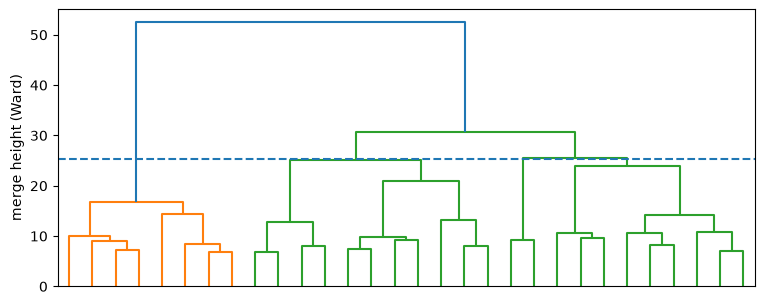

In [21]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(9, 3.6))
dendrogram(tree, truncate_mode="lastp", p=30, no_labels=True, ax=ax)
cut = (tree[-4, 2] + tree[-3, 2]) / 2
ax.axhline(cut, linestyle="--")
ax.set_ylabel("merge height (Ward)")
plt.show()

**How it works:** `tree[-3, 2]` is the height of the third-from-last merge, the one that would join four groups into three, and `tree[-4, 2]` the merge before it. A line halfway between them, drawn with `ax.axhline` (`linestyle="--"` makes it dashed), crosses exactly four branches: the cut into four clusters. `no_labels=True` hides the leaf labels, and `figsize=(9, 3.6)` is the picture's width and height in inches, as in Chapter 18. Figure 38.4 is this picture, redrawn in the book's style.

![A dendrogram of 800 sampled accounts showing the last 30 merges, with the merge height on the vertical axis, a dashed line where a cut produces four clusters, and the four branches labeled with their sizes and main k-means group: 147 accounts, 88% key accounts; 287, 48% growing regulars; 50, 94% drifting away; 316, 85% occasional buyers](figures/fig38-4-dendrogram.svg)

*Figure 38.4 — A dendrogram of 800 accounts (Ward linkage, last 30 merges). Each merge is drawn at the height that measures how different the merged groups were; cutting across the tree at a chosen height gives that many clusters. Each of the four branches is coloured and marked like the k-means cluster most of its accounts belong to, with that share underneath.*

**Reading it.** Cut into four, the tree gives clusters of 147, 287, 50, and 316 accounts, and it agrees with the k-means grouping to an ARI of 0.413: related, but far from the same. The two methods cut a continuous cloud in different places, another reminder that these groups are conveniences rather than discoveries. Hierarchical clustering earns its place when you want the tree itself: a picture of which groups sit inside which, which product ranges or store types nest together.

---

## 38.5 DBSCAN

### How it works

**DBSCAN** (density-based spatial clustering of applications with noise) doesn't take *k*. It grows clusters from **dense** regions:

- A row is a **core point** if at least `min_samples` rows lie within a radius `eps` of it. The row itself counts toward `min_samples`.
- Core points that are within `eps` of each other join the same cluster. A non-core row within `eps` of a core point is a **border point**: it joins that cluster at the edge.
- Everything else is labeled **noise** (`-1`), and isn't in any cluster.

### By hand, on a line

Take eight values on a line, 1, 2, 3, 4, 10, 11, 12 and 25, with `eps` = 1.5 and `min_samples` = 3:

- **2** has 1, 2 and 3 within 1.5 of it: three rows, so it's a core point. So is **3** (2, 3, 4) and **11** (10, 11, 12).
- **1** has only 1 and 2 within reach: two rows, not core. But it's within 1.5 of the core point 2, so it's a border point of cluster 0. **4** is the same, beside 3.
- 2 and 3 are within 1.5 of each other, so they're in one cluster: {1, 2, 3, 4} is cluster 0.
- **10** and **12** are border points of 11's cluster: {10, 11, 12} is cluster 1.
- **25** has nothing within reach: noise.

In [22]:
from sklearn.cluster import DBSCAN

line = np.array([1, 2, 3, 4, 10, 11, 12, 25]).reshape(-1, 1)
print(DBSCAN(eps=1.5, min_samples=3).fit(line).labels_)

[ 0  0  0  0  1  1  1 -1]


**How it works:** scikit-learn expects a table, rows × columns, even for a single feature, so **`.reshape(-1, 1)`** turns the eight values into eight rows of one column (`-1` means "as many rows as needed"). `.fit(line).labels_` runs DBSCAN and returns each row's cluster: the hand answer, with 25 as `-1`.

Two properties follow. DBSCAN finds clusters of **any shape**, including long curved ones that defeat k-means, and it **refuses to classify** rows in sparse regions, which is useful when you want only the well-defined groups.

### Choosing min_samples and eps

A common starting point for `min_samples` is twice the number of features: 2 × 7 = **14** here. For `eps`, the standard tool is the **k-distance plot**: for every row, the distance to its 14th-nearest neighbour, sorted from smallest to largest. Where the curve bends sharply upwards, rows stop having dense neighbourhoods, and that height is a sensible `eps`.

 10% of accounts have a 14th neighbour within 0.66
 25% of accounts have a 14th neighbour within 0.77
 50% of accounts have a 14th neighbour within 0.94
 75% of accounts have a 14th neighbour within 1.16
 90% of accounts have a 14th neighbour within 1.42
 99% of accounts have a 14th neighbour within 2.13


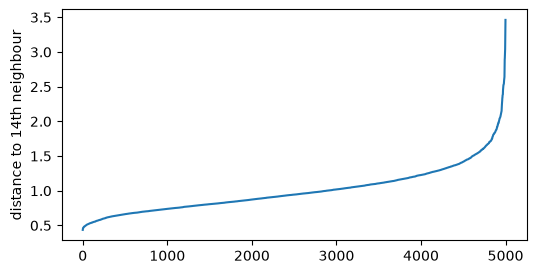

In [23]:
from sklearn.neighbors import NearestNeighbors

neighbours = NearestNeighbors(n_neighbors=14).fit(X)
dist, _ = neighbours.kneighbors(X)
k_distance = np.sort(dist[:, -1])
for share in [0.10, 0.25, 0.50, 0.75, 0.90, 0.99]:
    within = np.quantile(k_distance, share)
    print(f"{share:>4.0%} of accounts have a 14th neighbour within {within:.2f}")
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(k_distance)
ax.set_ylabel("distance to 14th neighbour")
plt.show()

**How it works:** `NearestNeighbors(n_neighbors=14)` finds each row's 14 nearest rows. Asked about the rows it was fitted on, the nearest of those is the row itself (distance 0), which matches DBSCAN counting the row itself toward `min_samples`. `kneighbors(X)` returns two arrays, the distances and the neighbours' row numbers; `dist, _ = …` keeps the first and throws the second away (`_` is Python's name for "not needed"). `dist[:, -1]` is each row's distance to its 14th neighbour, and `np.sort` puts them in order for the plot. `np.quantile(k_distance, share)` reads the curve at a few points, and `ax.plot(k_distance)` draws it on a 6 × 3 inch figure (`figsize`) (Figure 38.5 is the same curve in the book's style).

![A rising curve of the 5,000 accounts' 14th-neighbour distances, sorted, climbing gently from under 0.5 to about 1.5 over most of the accounts and then steeply at the far right, with dotted lines at eps values 0.5, 0.8, 1.0 and 1.2 crossing it at different points](figures/fig38-5-k-distance.svg)

*Figure 38.5 — The k-distance curve for Riverstone's accounts. There's no sharp knee, only a gentle climb and a steep tail: a first sign that the accounts have no dense groups separated by empty space.*

The curve climbs steadily with no clear knee, so it suggests a range rather than a value. Sweep `eps` across that range. This is the chapter's "what happens if you change it" experiment: predict, before you run it, what a small `eps` and a large one will do.

In [24]:
print(" eps   clusters   noise points")
for eps in [0.5, 0.8, 1.0, 1.2, 1.6]:
    labels = DBSCAN(eps=eps, min_samples=14).fit_predict(X)
    n_clusters = len(set(labels)) - (1 if -1 in labels else 0)
    print(f"{eps:>4}   {n_clusters:>8}   {(labels == -1).sum():>12,}")

 eps   clusters   noise points


 0.5          2          4,825


 0.8          6          2,430


 1.0          1          1,047


 1.2          1            393


 1.6          1             66


**How it works:** `set(labels)` keeps each distinct label once, and `len` counts them. Noise, `-1`, isn't a cluster, so **`- (1 if -1 in labels else 0)`** subtracts one when `-1` is among the labels: "count the distinct labels, not counting −1". `(labels == -1).sum()` counts the noise rows.

At `eps` = 0.8 the sweep finds several clusters. How big are they?

In [25]:
labels = DBSCAN(eps=0.8, min_samples=14).fit_predict(X)
print(pd.Series(labels).value_counts().to_string())

-1    2430
 0    1579
 2     544
 1     218
 3     205
 5      13
 4      11


**Reading it.** Every value of `eps` gives an unsatisfying answer. Small radii (0.5) leave 4,825 of 5,000 accounts as noise; large radii (1.0 and up) swallow almost everything into one cluster. In between, `eps` = 0.8 gives six clusters, but they aren't balanced: one of 1,579 accounts, three of a few hundred, two of a handful, and 2,430 accounts left as noise. The reason is section 38.2's: this cloud has no genuine gaps for DBSCAN to find. **On this data, DBSCAN's honest answer is that there are no density-separated groups.**

That's worth taking seriously rather than tuning away. DBSCAN shines on spatial data (delivery points, sensor readings, GPS traces), where dense regions and empty space really exist, and it doubles as an anomaly detector: the noise points are the odd ones out.

**Key settings:** `eps` (the radius: read the k-distance plot, then sweep it as above) and `min_samples` (start at twice the number of features; larger values demand denser clusters and leave more noise).

---

## 38.6 Seeing many dimensions: PCA, t-SNE, UMAP

Seven features can't be drawn. Three methods squeeze them into two dimensions for a picture:

- **PCA** (the method you ran by hand in section 35.10) finds the straight-line directions of greatest variance. It's fast, deterministic, reversible if you keep all the components, and its axes have meaning through their **loadings**, the weight each feature gets in each component. It can't unfold curved structure.
- **t-SNE** places rows so that each row's **near neighbours** stay near, allowing the map to bend. It's excellent at showing local groupings, slow on large data, and its global layout (distances between blobs, blob sizes) is not meaningful.
- **UMAP** does something similar, usually faster, and preserves a little more of the global structure. Both have random starts and settings that change the picture (the table below).

PCA first:

In [26]:
from sklearn.decomposition import PCA

pca = PCA().fit(X)
print("PCA share of variance:", pca.explained_variance_ratio_[:4].round(3))
print(
    "first two components together:", f"{pca.explained_variance_ratio_[:2].sum():.1%}"
)
coords_pca = pca.transform(X)[:, :2]

PCA share of variance: [0.397 0.143 0.136 0.121]
first two components together: 54.1%


**How it works:** `PCA().fit(X)` finds all seven components; `explained_variance_ratio_` is each one's share of the total variance (section 35.10). `pca.transform(X)` gives every account's position on the components, and `[:, :2]` keeps the first two, the picture's two axes.

What do those two axes mean? The loadings say:

In [27]:
loadings = pd.DataFrame(pca.components_[:2], columns=FEATURES, index=["PC1", "PC2"])
print(loadings.T.round(2).to_string())

                        PC1   PC2
log_revenue            0.55 -0.00
orders_2024            0.54  0.02
categories_bought      0.29  0.05
avg_discount_pct       0.41 -0.01
late_payment_days     -0.16  0.25
days_since_last_order -0.36 -0.02
tenure_months          0.02  0.97


**Reading it.** **PC1 is size and activity**: revenue (0.55), orders (0.54), discount (0.41) and categories (0.29) all push it up, and days since the last order (−0.36) pulls it down. Big, busy, recent accounts sit far to one side. **PC2 is almost pure tenure** (0.97): how long they've been a customer. (The signs are arbitrary; PCA could flip a whole column.)

Now t-SNE and UMAP, on a sample of 1,500 accounts to keep t-SNE quick:

In [ ]:
from sklearn.manifold import TSNE
import umap

plot_rows = np.random.default_rng(38).choice(len(X), size=1500, replace=False)
coords_tsne = TSNE(n_components=2, perplexity=30, random_state=38).fit_transform(
    X[plot_rows]
)
coords_umap = umap.UMAP(n_components=2, random_state=38).fit_transform(X[plot_rows])
print(f"t-SNE on {len(plot_rows):,} accounts, output shape {coords_tsne.shape}")
print("UMAP output shape:", coords_umap.shape)

> **Not run here.** This cell needs something this machine does not have: a database, an API key, a running service, or command-line arguments. Run it on your own machine, with the setup the chapter describes, and you should see what the chapter shows.

**What the chapter shows:**

```
t-SNE on 1,500 accounts, output shape (1500, 2)
UMAP output shape: (1500, 2)
```

UMAP prints a warning here, that setting `random_state` makes it run on a single processor core. That's the price of a picture that comes out the same every time, and it's harmless. The settings:

| Setting | What it means | What happens if you change it |
|---|---|---|
| `n_components=2` | How many dimensions to squeeze into | 2 for a flat picture; 3 for a 3-D one |
| `perplexity=30` (t-SNE; 30 is the default) | Roughly how many neighbours each point pays attention to | Lower: many small, tight islands. Higher: fewer, broader shapes. Must be well below the number of rows |
| `n_neighbors` (UMAP; default 15, not set above) | UMAP's version of the same idea | Lower: more local detail. Higher: more of the big picture |
| `min_dist` (UMAP; default 0.1, not set above) | How tightly points may be packed | Lower: dense clumps. Higher: points spread more evenly |
| `random_state=38` | Fixes the random start | Leave it out and the picture changes every run |

Draw the three pictures side by side, each account coloured by its k-means cluster:

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
pictures = [
    ("PCA", coords_pca[plot_rows]),
    ("t-SNE", coords_tsne),
    ("UMAP", coords_umap),
]
for ax, (title, coords) in zip(axes, pictures):
    ax.scatter(coords[:, 0], coords[:, 1], c=base[plot_rows], s=4, cmap="tab10")
    ax.set_title(title)
plt.show()

> **Not run here.** This cell depends on a cell above that could not run here, so its names were never created. Run it on your own machine, with the setup the chapter describes, and you should see what the chapter shows.

**How it works:** `plt.subplots(1, 3, figsize=(12, 4))` makes one row of three panels, `axes`, on a 12 × 4 inch figure. `pictures` pairs each title with its coordinates; for PCA, `coords_pca[plot_rows]` picks the same 1,500 accounts. `zip(axes, pictures)` walks through both lists together. `ax.scatter(x, y, c=..., s=4, cmap="tab10")` draws a dot per account (`s` is the dot size), coloured by its cluster label through the colour set `tab10`. Figure 38.6 is this picture in the book's style, with a different marker shape for each cluster, so it reads in black and white too.

![Three scatter panels of the same 1,500 accounts, each account drawn with its k-means cluster's colour and marker shape: PCA shows a continuous cloud with clusters in overlapping bands, t-SNE shows the groups as touching regions, and UMAP shows a few connected arms, with the same groups appearing in each](figures/fig38-6-pca-tsne-umap.svg)

*Figure 38.6 — The same accounts under PCA, t-SNE, and UMAP, marked by their k-means cluster. The clusters hold together in all three, and in all three they're touching, not separated: the same continuum the silhouette reported.*

**Reading it.** PCA's first two components hold 54.1% of the variance, so the flat picture is missing nearly half the information. t-SNE and UMAP pull the groups a little further apart than PCA does, but even there they touch, and that extra separation is partly a property of the methods, not of Riverstone's customers.

> **Watch out: don't over-read a t-SNE or UMAP picture.** The distance between two blobs, the size of a blob, and the empty space between them carry little meaning; those methods are free to stretch and shrink regions. Never feed t-SNE coordinates into a predictive model as features, and never present one as evidence that groups are "clearly separated". Use them to explore and to illustrate, then verify with numbers.

---

## 38.7 Anomaly detection

### Isolation forests

An **isolation forest** finds rows that are quick to isolate. It builds many random trees: at each step it picks a random feature and a random split point. Ordinary rows sit in crowded regions and need many splits to be separated; unusual rows get cut off after a few. The average number of splits needed becomes the **anomaly score**.

**By hand, on five values:** 10, 11, 12, 13 and 50. A random cut falls somewhere between the smallest and the largest value, 10 and 50. Any cut between 13 and 50, 37 of the 40 units of that range, isolates 50 at once: one split. To isolate 11, a cut must fall between 10 and 11 **and** another between 11 and 12, each a 1-unit slot, so it usually takes several splits. Averaged over many random trees, 50 needs far fewer splits than anything else.

In [30]:
from sklearn.ensemble import IsolationForest

values = np.array([10, 11, 12, 13, 50]).reshape(-1, 1)
tiny = IsolationForest(random_state=38).fit(values)
print(tiny.score_samples(values).round(2))

[-0.43 -0.34 -0.35 -0.45 -0.73]


**How it works:** `.reshape(-1, 1)` makes one column again. `IsolationForest(random_state=38).fit(values)` grows the random trees (100 by default), seeded so the result repeats. `score_samples` turns each value's average number of splits into a score: **the lower, the stranger**. 50 scores lowest by far (−0.73); 11 and 12, in the middle of the crowd, score highest (−0.34 and −0.35).

It's fast, it handles many features, and it needs no labels. On the accounts:

In [31]:
forest = IsolationForest(contamination=0.02, random_state=38).fit(X)
accounts["outlier_score"] = forest.decision_function(X)  # lower = stranger
flagged = accounts.nsmallest(100, "outlier_score")
print(
    f"100 strangest accounts: churn rate {flagged['churned_2025'].mean():.1%} "
    f"vs {accounts['churned_2025'].mean():.1%} overall"
)
columns = [
    "segment",
    "revenue_2024",
    "orders_2024",
    "late_payment_days",
    "days_since_last_order",
    "churned_2025",
]
print(accounts.nsmallest(5, "outlier_score")[columns].to_string(index=False))

100 strangest accounts: churn rate 21.0% vs 9.7% overall


  segment  revenue_2024  orders_2024  late_payment_days  days_since_last_order  churned_2025
Wholesale     7966300.0           77               40.0                    7.0             0
Wholesale     1551400.0           82               45.0                    3.0             0
   Retail       94600.0            2               63.0                  365.0             1
Wholesale     4152200.0           62               32.0                   10.0             0
Wholesale     3042000.0           68               55.0                    3.0             1


**How it works:** `decision_function(X)` gives each account a score on the same "lower is stranger" scale as `score_samples`, shifted so that 0 is the line between normal and anomaly. `nsmallest(100, "outlier_score")` takes the 100 lowest, the strangest, and the second print shows the five strangest with six of their columns. **`contamination=0.02`** sets where that line is drawn: the share of rows `forest.predict(X)` would label as anomalies (2% of 5,000 is 100, the number we inspect). The **ranking** we use doesn't depend on it: with any `contamination`, the same 100 accounts come out strangest.

**Reading it.** Among the 100 strangest accounts, 21% churned in 2025, against 9.7% overall. The flagged accounts fall into two kinds: enormous wholesale accounts that are unusual because nothing else is that large, and tiny accounts with a couple of orders and a last order a year or more ago (365 is the file's cap). Both are worth a human look, for opposite reasons.

That points at how anomaly detection is used in practice: **as a review queue, not a decision**. Nobody should be dropped because a model called them unusual. Typical uses are fraud triage (Chapter 39's cost thinking applies), data quality checks (an account with a 60% discount is probably a data-entry error), and sensor monitoring (Chapter 40 does this over time).

**Other tools for the same job:** `LocalOutlierFactor` (compares a row's local density with its neighbours'), `OneClassSVM` (learns a boundary around normal data), and DBSCAN's noise points. For anomalies over time, forecasting residuals work better (Chapter 40).

---

## 38.8 Judging unsupervised results

With no target, there are four kinds of evidence, in rising order of usefulness:

1. **Internal measures** (silhouette, inertia, and the Davies–Bouldin index, `davies_bouldin_score`, the average ratio of a cluster's spread to its distance from the nearest other cluster, where lower is better) score how compact and separated the clusters are, using only the features. They're comparable between runs on the same data, and they never prove that groups are real.
2. **Stability** (section 38.2) asks whether the same structure appears on different samples and seeds. Low stability is fatal; high stability is reassuring.
3. **External checks** compare the groups with something they were never given.
4. **Business usefulness**: can each group be described in a sentence and treated differently, and does acting on it change a number the company cares about? That's the one that matters, and it usually needs an experiment (Chapter 30).

The external check here: the clusters were built without any churn information. How much do they know about it?

In [32]:
from sklearn.metrics import roc_auc_score

rates = accounts.groupby("cluster")["churned_2025"].mean()
scored = accounts["cluster"].map(rates)
print("churn rate by cluster:", rates.round(3).to_dict())
auc = roc_auc_score(accounts["churned_2025"], scored)
print(f"using the cluster alone to rank churn risk: AUC {auc:.3f}")
print("(Chapter 37's supervised models scored 0.80 to 0.85 on this target.)")

churn rate by cluster: {0: 0.026, 1: 0.035, 2: 0.08, 3: 0.405}
using the cluster alone to rank churn risk: AUC 0.759
(Chapter 37's supervised models scored 0.80 to 0.85 on this target.)


**How it works:** `rates` is each cluster's churn rate, and `.map(rates)` gives every account its cluster's rate as a score. `roc_auc_score` (Chapter 36, section 36.5) measures how well that score ranks churners above stayers.

**Reading it.** Ranking accounts by their cluster's churn rate gives an AUC of 0.759, against 0.80–0.85 for the supervised models in Chapter 37 that were trained on churn directly. Four unlabelled groups recover much of the ranking power of a model built for the job. Two cautions make the check weaker than it sounds. Recency, the strongest churn signal in Chapter 37 (an odds ratio of 2.10 in section 37.3), was one of the clustering features, so some of this was built in. And the 0.759 is measured on the same accounts the rates came from, while Chapter 37's scores are on accounts its models hadn't seen. Still, it's a genuine external check, and also a caution: **when you have a target, use it.** Clustering isn't a substitute for a supervised model; it's what you reach for when there's no target at all, or when you need groups people can hold in their heads.

### Checkpoint: the end of the second week

Before section 38.9, check that the other methods are yours. Six values sit on a line: 2, 3, 7, 8, 9 and 20.

1. By hand, merge them with single linkage. At what heights do the merges happen, and which two groups are left just before the last merge?
2. By hand, run DBSCAN with `eps` = 1.5 and `min_samples` = 3. Which values are core points, which are border points, and which are noise?
3. An isolation forest scores the six values. Which one scores lowest, and why?

Check each answer with `linkage`, `DBSCAN`, and `IsolationForest`. (Answers at the end of the chapter.)

---

## 38.9 Market basket analysis

### The question and the vocabulary

*"Which products sell together?"* The data is Riverstone's 2025 order lines: one row per product per order. A **basket** is one order, and the analysis counts how often sets of products appear in the same basket. The two files:

| File | Columns | Example row |
|---|---|---|
| `order_lines.csv` | `order_id`, `account_id`, `order_date`, `product_id`, `quantity` | 900001, 5001, 2025-06-02, P09, 5 |
| `products.csv` | `product_id`, `product_name`, `category`, `unit_price` | P01, Storage Crate 50L, Storage, 620 |

Load them, attach each line's product name and its account's segment, and look:

In [33]:
lines = pd.read_csv("../baskets/order_lines.csv")
products = pd.read_csv("../baskets/products.csv")
lines = lines.merge(
    products[["product_id", "product_name", "category"]], on="product_id"
)
lines = lines.merge(accounts[["account_id", "segment"]], on="account_id")
print(
    f"{lines['order_id'].nunique():,} orders, {len(lines):,} order lines, "
    f"{lines['product_name'].nunique()} products, "
    f"{lines['account_id'].nunique():,} accounts"
)
basket_sizes = lines.groupby("order_id").size()
print(
    "products per order: median",
    int(basket_sizes.median()),
    " mean",
    round(basket_sizes.mean(), 2),
    " max",
    int(basket_sizes.max()),
)
print(lines["product_name"].value_counts().head(5).to_string())

34,013 orders, 92,337 order lines, 24 products, 4,516 accounts
products per order: median 2  mean 2.71  max 10
product_name
Airtight Seal Pack    7270
Crate Lid (50L)       6527
Crate Lid (80L)       6349
Drum Tap Fitting      5418
Stacking Bin Large    5280


**How it works:**

- **`merge(..., on="product_id")`** attaches each line's product name and category, and the second `merge` attaches the account's segment (Chapter 18, section 18.7). A `merge` keeps only rows that match on both sides, an inner join; every line has a product and an account, so no line is lost.
- **`nunique()`** counts distinct values: orders, products and accounts.
- **`groupby("order_id").size()`** counts the lines in each order, the basket sizes.
- **`value_counts().head(5)`** lists the five products on the most lines.

**Reading it.** 4,516 accounts appear, exactly the accounts that didn't churn in Chapter 37: churners placed no 2025 orders, a small consistency check between the two datasets. Each order has at most one line per product, so these counts are also the number of orders containing each product.

Three measures describe a rule such as *Storage Crate 50L → Crate Lid (50L)*:

> **support** = share of all baskets containing the items (how common the pattern is)
>
> **confidence** = share of baskets containing the "if" item that also contain the "then" item
>
> **lift** = confidence ÷ the "then" item's own support (how much more likely than chance)

Lift is the key one. Lift of 1 means the two are independent; 3 means they appear together three times as often as chance would predict; below 1 means they repel each other.

### Worked by hand

Of 34,013 orders, 4,239 contain a Storage Crate 50L, 6,527 contain a Crate Lid (50L), and 2,800 contain both:

> support(crate) = 4,239 ÷ 34,013 = 0.1246
>
> support(lid) = 6,527 ÷ 34,013 = 0.1919
>
> support(both) = 2,800 ÷ 34,013 = 0.0823
>
> confidence(crate → lid) = 0.0823 ÷ 0.1246 = **0.661**
>
> lift = 0.661 ÷ 0.1919 = **3.44**

Two thirds of crate orders include the matching lid, and that's 3.4 times the rate for orders in general.

First turn the lines into baskets, one set of product names per order:

In [34]:
baskets = lines.groupby("order_id")["product_name"].apply(set)
for order_id, items in baskets.head(3).items():
    print(order_id, sorted(items))

900001 ['Airtight Seal Pack', 'Chopping Board', 'Food Container 5L', 'Storage Crate 50L']
900002 ['Food Container 5L']
900003 ['Folding Stool', 'Shelf Unit 4-Tier']


**How it works:** `groupby("order_id")["product_name"]` gathers each order's product names, and **`.apply(set)`** collects them into a **set**, a bag with no duplicates and no order (Chapter 17, section 17.7). `baskets` is a Series: one set per order, indexed by order number. `.head(3).items()` hands over the first three as (order number, set) pairs, and `sorted(items)` prints each set as an alphabetical list, because a set has no order of its own and could print its items in any order.

Now the three measures in code:

In [35]:
n_orders = len(baskets)
crate = baskets.apply(lambda s: "Storage Crate 50L" in s)
lid = baskets.apply(lambda s: "Crate Lid (50L)" in s)

support_a = crate.mean()
support_b = lid.mean()
support_ab = (crate & lid).mean()
confidence = support_ab / support_a
lift = confidence / support_b
print(f"orders: {n_orders:,}")
print(f"support(Storage Crate 50L)          {support_a:.4f}  ({crate.sum():,} orders)")
print(f"support(Crate Lid 50L)              {support_b:.4f}  ({lid.sum():,} orders)")
n_both = (crate & lid).sum()
print(f"support(both)                       {support_ab:.4f}  ({n_both:,} orders)")
print(f"confidence(Crate 50L -> Lid 50L)    {confidence:.4f}")
print(f"lift                                {lift:.2f}")

orders: 34,013
support(Storage Crate 50L)          0.1246  (4,239 orders)
support(Crate Lid 50L)              0.1919  (6,527 orders)
support(both)                       0.0823  (2,800 orders)
confidence(Crate 50L -> Lid 50L)    0.6605
lift                                3.44


**How it works:** `baskets.apply(lambda s: "Storage Crate 50L" in s)` asks each basket "does it contain a 50-litre crate?" and gives a True/False Series (`lambda` is Chapter 18's function without a name). The mean of True/False values is the share of Trues, the support. `crate & lid` is True only where both are, and the confidence and lift follow the formulas above.

### Apriori: finding the rules automatically

Checking every possible rule is expensive: 24 products give 276 pairs and thousands of larger sets. The **Apriori** algorithm prunes the search with one observation: *if a set of items is rare, every larger set containing it is at least as rare.* So it finds items above a minimum support, then pairs, then triples, never looking at extensions of sets that already failed.

**By hand, on five baskets:** {chair, table}, {chair, table, cushion}, {chair}, {lid, crate}, {lid}, with a minimum support of 40% (2 of the 5 baskets).

- **Single items:** chair 3 of 5 = 60%, table 40%, lid 40% pass; cushion 20% and crate 20% fail.
- **Pairs:** Apriori only builds pairs from the items that passed: {chair, table} 40% passes; {chair, lid} and {table, lid} are 0%. Any pair containing cushion or crate is **never checked**, because a set containing a failed item can't be more common than that item.
- **Triples:** a triple would need at least two passing pairs to build from; there's only one, so the search stops.

In [ ]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

five = [
    ["chair", "table"],
    ["chair", "table", "cushion"],
    ["chair"],
    ["lid", "crate"],
    ["lid"],
]
encoder = TransactionEncoder()
grid = pd.DataFrame(encoder.fit_transform(five), columns=encoder.columns_)
print(grid.to_string())
found = apriori(grid, min_support=0.4, use_colnames=True)
found["items"] = found["itemsets"].apply(sorted)
print(found[["support", "items"]].to_string())

> **Not run here.** This cell needs something this machine does not have: a database, an API key, a running service, or command-line arguments. Run it on your own machine, with the setup the chapter describes, and you should see what the chapter shows.

**What the chapter shows:**

```
   chair  crate  cushion    lid  table
0   True  False    False  False   True
1   True  False     True  False   True
2   True  False    False  False  False
3  False   True    False   True  False
4  False  False    False   True  False
   support           items
0      0.6         [chair]
1      0.4           [lid]
2      0.4         [table]
3      0.4  [chair, table]
```

**How it works:**

- **`TransactionEncoder`** turns a list of baskets into a table of True/False columns, one per product, one row per basket: the format `apriori` needs. `fit_transform` does it, and `encoder.columns_` holds the product names for the column headings.
- **`apriori(grid, min_support=0.4, use_colnames=True)`** finds every item set in at least 40% of baskets. `use_colnames=True` shows product names instead of column numbers. Its `itemsets` column holds **frozensets**, sets that can't be changed after they're made; `.apply(sorted)` turns each into an alphabetical list for printing, in a new column `items`. The four sets found are exactly the hand answer: chair, lid, table, and {chair, table}.

The same on Riverstone's 34,013 baskets. `association_rules` then turns the frequent sets into if-then rules and scores them:

In [ ]:
encoder = TransactionEncoder()
matrix = pd.DataFrame(encoder.fit_transform(baskets.tolist()), columns=encoder.columns_)
print(matrix.shape, "baskets x products")
frequent = apriori(matrix, min_support=0.01, use_colnames=True)
rules = association_rules(frequent, metric="lift", min_threshold=1.2)
rules["if"] = rules["antecedents"].apply(lambda s: ", ".join(sorted(s)))
rules["then"] = rules["consequents"].apply(lambda s: ", ".join(sorted(s)))
rules["rule"] = rules["if"] + " -> " + rules["then"]
print(f"{len(frequent)} frequent item sets, {len(rules)} rules with lift above 1.2")
top = rules.sort_values(["lift", "rule"], ascending=[False, True]).head(8)
print(top[["rule", "support", "confidence", "lift"]].round(3).to_string(index=False))

> **Not run here.** This cell depends on a cell above that could not run here, so its names were never created. Run it on your own machine, with the setup the chapter describes, and you should see what the chapter shows.

**What the chapter shows:**

```
(34013, 24) baskets x products
183 frequent item sets, 198 rules with lift above 1.2
                                       rule  support  confidence  lift
               Garden Chair -> Garden Table    0.032       0.508 9.005
               Garden Table -> Garden Chair    0.032       0.571 9.005
          Chair Cushion Set -> Garden Chair    0.022       0.348 5.489
          Garden Chair -> Chair Cushion Set    0.022       0.353 5.489
   Drum 60L -> Drum Tap Fitting, Pallet Box    0.011       0.108 4.812
   Drum Tap Fitting, Pallet Box -> Drum 60L    0.011       0.484 4.812
Crate Trolley, Drum Tap Fitting -> Drum 60L    0.011       0.477 4.747
Drum 60L -> Crate Trolley, Drum Tap Fitting    0.011       0.109 4.747
```

**How it works:**

- `baskets.tolist()` hands the encoder the 34,013 sets; `matrix` has one row per basket and one True/False column per product.
- `apriori` keeps item sets in at least 1% of baskets (`min_support=0.01`, about 340 orders).
- **`association_rules(frequent, metric="lift", min_threshold=1.2)`** makes every if-then rule from those sets and keeps the ones whose `lift` is at least 1.2. Its **`antecedents`** column is the "if" side and **`consequents`** the "then" side, each a frozenset.
- `", ".join(sorted(s))` turns a frozenset into readable text such as `Drum Tap Fitting, Pallet Box`, and `rule` joins the two sides with an arrow.
- `sort_values(["lift", "rule"], ascending=[False, True])` puts the highest lift first (`False` means largest first); rules with equal lift, such as a pair read in both directions, then go in alphabetical order, so they print the same way every run. `head(8)` keeps eight.

**Reading it.** The strongest rules are the planted ones and they're the ones a warehouse manager would recognize: garden chairs with garden tables (lift 9.0), chairs with cushions (5.5), drums with tap fittings. Rules go in both directions with the same lift but different confidence: 57.1% of table buyers add chairs, while 50.8% of chair buyers add a table, because chairs are more common overall.

### The confidence trap

Confidence alone is misleading, because a very common product has high confidence with everything:

In [38]:
common = "Crate Lid (50L)"
has_common = baskets.apply(lambda s: common in s)
for item in ["Chopping Board", "Serving Tray", "Folding Stool"]:
    has_item = baskets.apply(lambda s: item in s)
    both = (has_item & has_common).mean()
    conf = both / has_item.mean()
    print(
        f"{item:<16} -> {common}: support {both:.4f}   confidence {conf:.3f}   "
        f"lift {conf / has_common.mean():.2f}"
    )

Chopping Board   -> Crate Lid (50L): support 0.0167   confidence 0.148   lift 0.77
Serving Tray     -> Crate Lid (50L): support 0.0178   confidence 0.155   lift 0.81
Folding Stool    -> Crate Lid (50L): support 0.0078   confidence 0.171   lift 0.89


**How it works:** the loop repeats the crate-and-lid calculation for three products, each against the common Crate Lid (50L). `f"{item:<16}"` pads the name to 16 characters, so the columns line up.

**Reading it.** A Crate Lid (50L) appears in 15% of baskets that contain a chopping board, which sounds like a pattern. Its lift is **0.77**: a chopping-board basket is *less* likely than average to contain a crate lid. The lid is common enough (19% of all baskets) that 15% is below chance. Always read confidence next to lift and support.

> **Watch out: three more basket traps.** (1) **Trivial rules:** "buys crate lid → buys crate" may be a packaging rule, not an insight. (2) **Support too low:** a rule holding in 12 of 34,013 baskets can have enormous lift and no business value; that's why `min_support` exists. (3) **Correlation isn't causation:** a rule says the two appear together, not that pushing one sells the other. Testing a bundle offer with an experiment (Chapter 30) is what proves it.

### Turning rules into money

A rule earns its keep when it points at a specific action:

In [39]:
drum_orders = set(lines.loc[lines["product_name"] == "Drum 60L", "order_id"])
tap_orders = set(lines.loc[lines["product_name"] == "Drum Tap Fitting", "order_id"])
missing = drum_orders - tap_orders
missing_accounts = lines.loc[lines["order_id"].isin(missing), "account_id"].nunique()
print(f"orders with Drum 60L: {len(drum_orders):,}")
share = len(missing) / len(drum_orders)
print(f"of those, without a Drum Tap Fitting: {len(missing):,} ({share:.1%})")
print(f"accounts placing at least one such order: {missing_accounts:,}")
segment_mix = (
    lines[lines["order_id"].isin(missing)].groupby("segment")["order_id"].nunique()
)
print("those orders by segment:", segment_mix.to_dict())

orders with Drum 60L: 3,418
of those, without a Drum Tap Fitting: 954 (27.9%)
accounts placing at least one such order: 591
those orders by segment: {'Hospitality': 33, 'Retail': 63, 'Wholesale': 858}


**How it works:**

- `lines.loc[condition, "order_id"]` picks the order numbers of the lines that match, and `set(...)` keeps each once: `drum_orders` is every order with a 60-litre drum, `tap_orders` every order with a tap fitting.
- **`drum_orders - tap_orders`** is set difference (Chapter 17, section 17.7): the drum orders with no tap.
- `lines["order_id"].isin(missing)` is True for the lines of those orders; `.nunique()` on their `account_id` counts the accounts that placed them.
- The last lines count those orders by segment.

**What to tell the sales head.** "Two thirds of orders containing a 50-litre crate already include the matching lid, and about 7 in 10 drum orders include a tap fitting. But 954 orders across 591 accounts, nearly all wholesale, had a 60-litre drum and no tap fitting. That's a checkout prompt, a pre-filled line on the order form, or a call from the account manager, and we can measure whether it works by trying it with half the accounts first."

Chapter 42 builds the next step: a recommender that scores products for each customer rather than working from global rules.

---

## Common mistakes

| Mistake | Symptom | Fix |
|---|---|---|
| Clustering unscaled features | Clusters differ only by the biggest-unit column | Standardize every feature first; use a pipeline (Chapter 36) when new accounts will be assigned to existing clusters later |
| Leaving skewed money columns raw | A handful of huge accounts dominate every distance | Log-transform first |
| Including the target in the features | "Clusters" that are the target in disguise | Cluster on descriptive features only; use the target as an external check |
| Choosing *k* by silhouette alone | *k* = 2 every time, and useless groups | Weigh elbow, silhouette, stability, and whether the business can act on the groups |
| Reporting clusters as discovered types | "Our customers fall into four natural groups" | Say "a convenient division of a continuum" when the silhouette is low |
| Comparing cluster numbers between runs | "Cluster 2 moved to cluster 0" | Compare groupings with the adjusted Rand index |
| No stability check | Groups change every time the data updates | Re-run with different seeds and on subsamples |
| Reading distances in a t-SNE or UMAP picture | "These two groups are far apart, so they're very different" | Treat those layouts as sketches; verify with numbers |
| Using t-SNE coordinates as model features | Unreproducible, unexplainable models | Use PCA if you need components as features |
| Hierarchical clustering on huge data | Memory errors or a very long wait | Cluster a sample, or use k-means |
| Tuning DBSCAN until it gives *k* clusters | Either everything is noise or everything is one cluster | Accept that there may be no density-separated groups |
| Treating anomalies as decisions | Customers cut off because a model called them odd | Use anomaly scores as a review queue |
| Judging rules by confidence | "Everything leads to our best-selling product" | Read lift and support alongside confidence |
| Acting on very rare rules | A bundle nobody buys | Set a sensible `min_support` for the business |
| Assuming a rule is causal | A bundle launch that changes nothing | Test it (Chapter 30) |

---

## In the real world: the four segments that already existed

In May 2026, Anita Rao asks Meera for "proper customer segments" before the annual sales planning meeting. The marketing agency Riverstone used two years ago delivered nine segments with names like *Urban Aspirants*; nobody ever used them.

Meera builds the clustering in this chapter and gets four groups. Before presenting anything, she does three checks.

**Does it survive re-running?** Different seeds and 80% samples give adjusted Rand scores above 0.96. The groups are stable.

**Does it know anything it wasn't told?** She never showed it churn. The drifting-away group's churn rate is 41%, against 2.6% for the regulars. It does.

**Does it match how the team already thinks?** This is the check that changes the meeting. She takes the four profiles to the three sales executives, without the cluster numbers, and asks how they'd describe their customers. Neha describes "my regulars", "the big wholesale accounts I babysit", "the ones who order once a quarter", and "the ones who stopped answering". Four groups, near enough the same four.

At the planning meeting, Meera doesn't present a model. She presents a table: four groups, what each is worth, how many accounts each contains, and which of the three executives owns most of each. The headline is the concentration: **19% of accounts produce 62% of revenue, and the 570 drifting accounts produce 2.3%.**

Anita's question is the right one: *"So what changes?"* Three things. Key accounts get quarterly reviews instead of ad-hoc contact. Growing regulars get the cross-sell campaign for their missing product category, which the basket rules in section 38.9 can fill in. And the drifting accounts get one scripted win-back call each, after which they stop receiving sales attention, which frees roughly a day a week across the team.

Vikram, skeptical, asks why the earlier agency's nine segments failed. Meera's answer: *"They were built from demographics we don't act on, and nobody could tell which segment a customer was in without asking the agency. Ours come from our own order data, we can re-run them every quarter, and any rep can work out a customer's group from three numbers: orders last year, categories bought, and days since the last order. That rule matches the full clustering for nine accounts in ten."*

Six months later, two of the four groups have been renamed by the sales team, which Meera counts as the clearest sign the work landed.

---

## Project: customer segmentation and a product-bundle analysis

**Goal:** a segmentation a sales team could use, and a short list of product bundles worth testing, both defended with evidence rather than a chart.

### Tools you'll need

- **scikit-learn** (tested on 1.9.1): `KMeans`, `DBSCAN`, `silhouette_score`, `silhouette_samples`, `adjusted_rand_score`, `PCA`, `TSNE`, `IsolationForest`, `NearestNeighbors`, `DecisionTreeClassifier`. `MiniBatchKMeans` handles millions of rows.
- **SciPy** for `linkage`, `dendrogram`, and `fcluster`, which give the tree and draw it.
- **umap-learn** 0.5.12 for UMAP and **mlxtend** 0.25.0 for `TransactionEncoder`, `apriori`, and `association_rules`, both installed in section 38.0 (`python -m pip install umap-learn mlxtend`). For very large baskets, the FP-Growth implementation in mlxtend is faster than Apriori.
- **In SQL:** basket counts are a self-join of order lines on `order_id` with a `product_a < product_b` filter (the self-join from section 12.10), which is often how a first pass is done on data too large to bring into pandas.
- Everything ran on one CPU core, Python 3.11.15, on 29 September 2026. The slowest step is t-SNE on 1,500 accounts, a few seconds.
- **Companion files:** `companion/generate_riverstone_accounts.py` (Chapter 37, seed 20237) and `companion/generate_riverstone_baskets.py` (seed 20238) build the two datasets; section 38.0 shows how to run them, and section 38.9 describes the basket files. `companion/ch38/account_features.py` does section 38.0's preparation in one call (`accounts, X = load_accounts()`). Run the chapter's code from `companion/ch38/`.

**Option A: your own data.** Any customer, product, or transaction table you can use. Remove personal details first.

**Option B: Riverstone.** `accounts.csv` and the basket files.

**Steps:**

1. **Choose features deliberately.** List every column and say why it's in or out. Exclude anything that is a target or an outcome.
2. **Prepare.** Log-transform skewed money columns, handle blanks, and scale.
3. **Cluster** with k-means for *k* = 2 to 8. Record inertia and silhouette, and plot both.
4. **Check stability** with at least three seeds and three 80% subsamples, reported as adjusted Rand scores, for every *k* you're considering.
5. **Choose *k*** and justify it in three sentences: what the numbers say, what the business can act on, and what you're giving up.
6. **Profile and name** each cluster, with size, value share, and two or three defining numbers. Every name must be a phrase a sales rep would use, and every claim in a name must be measured.
7. **Cross-check** with one method you didn't use (hierarchical or DBSCAN) and one external column the clustering never saw.
8. **Draw one picture** (PCA, and optionally t-SNE or UMAP), with a caption that says what the picture does *not* prove.
9. **Basket analysis:** run Apriori, keep rules above a support and lift you justify, and remove trivial ones.
10. **Write a one-page recommendation:** the groups, what changes for each, two bundles to test, and how you'd measure whether any of it worked.

**Stretch goals:**

- Cluster on **behavior over time** instead of totals: build monthly order counts per account and cluster the 12-number sequences.
- Try **RFM** (recency, frequency, monetary value), the classic retail segmentation, and compare it with your clusters using the adjusted Rand index.
- Use **Gaussian mixture models** (`GaussianMixture`), which give each account a probability of belonging to each group instead of a hard label, and compare with k-means.
- Run basket analysis **per segment** and see whether the rules differ between wholesale and hospitality baskets.

---

## Recap

- **Unsupervised learning** finds structure without a target, and has no test set to prove it right.
- **k-means** alternates assigning rows to the nearest **centroid** and moving centroids to their members' average, minimizing **inertia**. Scale first; set `n_init`; labels are arbitrary.
- Choose ***k*** with the **elbow**, the **silhouette**, **stability** (adjusted Rand across seeds and subsamples), and above all whether the business can act on the groups. On continuous data, expect low silhouettes and say so.
- **Profile and name** clusters with size, value share, and defining numbers, and measure any claim a name makes.
- **Hierarchical clustering** builds a **dendrogram** you can cut at any height; Ward linkage is the usual default; it doesn't scale to large data.
- **DBSCAN** grows clusters from dense regions and labels the rest **noise**; it finds any shape and refuses to invent groups where there are none. The k-distance plot guides `eps`.
- **PCA** is fast and its loadings give its axes meaning; **t-SNE** and **UMAP** show local neighbourhoods but not global distances, and are for pictures, not features.
- **Isolation forests** score how easily a row is separated: a review queue for odd accounts, fraud triage, and data errors.
- **Market basket analysis** measures **support**, **confidence**, and **lift**; **Apriori** finds rules efficiently by never extending a set that failed; read lift and support alongside confidence, and test a bundle before believing it.
- Judge unsupervised work by **stability**, an **external check**, and whether a decision changes.

---

## Key terms

unsupervised learning · clustering · k-means · centroid · inertia · assignment step · update step · k-means++ · `n_init` · broadcasting · elbow method · silhouette score · adjusted Rand index (ARI) · stability · cluster profiling · RFM · hierarchical clustering · agglomerative · dendrogram · linkage (Ward, complete, average, single) · cutting the tree · DBSCAN · density · core point · border point · `eps` · `min_samples` · noise points · k-distance plot · dimensionality reduction · PCA · explained variance · loadings · t-SNE · perplexity · UMAP · local versus global structure · anomaly detection · isolation forest · contamination · market basket analysis · basket (transaction) · item set · support · confidence · lift · Apriori · frozenset · trivial rule · external validation · Davies–Bouldin index

*Also met in passing and in the exercises:* local outlier factor · FP-Growth · Gaussian mixture model

*(All terms are defined in the Glossary, Appendix A.)*

---

## Check yourself

- [ ] I can explain the two steps of k-means and run them by hand on a handful of rows.
- [ ] I always scale (and log skewed money) before any distance-based method.
- [ ] I choose *k* using the elbow, the silhouette, stability, and business usefulness together, and I say when the data has no natural groups.
- [ ] I can work out one row's silhouette by hand, and I compare two clusterings with the adjusted Rand index rather than by cluster number.
- [ ] I profile and name clusters so that someone who has never seen the model can use them.
- [ ] I can merge a few points by hand into a dendrogram and say what cutting it at a given height does.
- [ ] I can mark core, border, and noise points by hand, and I know when density-based clustering is the right tool.
- [ ] I can explain why t-SNE and UMAP pictures shouldn't be read for distances, and why PCA components can be used as features but t-SNE coordinates shouldn't.
- [ ] I can use an isolation forest to build a review queue, and I never let it make the decision.
- [ ] I can calculate support, confidence, and lift by hand, prune a small Apriori search by hand, and explain why a high-confidence rule can still be worthless.
- [ ] I judge an unsupervised result by stability, an external check, and whether anything changes because of it.

---

## Exercises

Code exercises run from `companion/ch38/` after the chapter's code (they use `accounts`, `X`, `FEATURES`, `base`, `lines`, `baskets`, `matrix`, and the rest). Predict each answer before running it.

### Warm-up

1. *(hand)* Two centroids sit at (0, 0) and (4, 4). Which cluster does the point (3, 1) join, and what is its squared distance to that centroid?
2. *(hand)* A cluster has 3 members at (2, 2), (4, 6), and (6, 4). Where is its centroid, and what is the cluster's contribution to inertia?
3. *(hand)* Of 1,000 baskets, 200 contain tea, 300 contain sugar, and 90 contain both. Calculate support, confidence, and lift for *tea → sugar*. Is the pattern worth reporting?
4. Which method fits each job: (a) group delivery points into service zones of any shape; (b) split 5,000 customers into four groups for four sales approaches; (c) show 20 features on one chart; (d) find 50 accounts worth a manual data check?

### Core

5. Re-run k-means on the same accounts **without scaling** the features. Profile the clusters and describe what happened.
6. Cluster with *k* = 5 and compare it with the *k* = 4 grouping using the adjusted Rand index. Which cluster split in two?
7. Add `complaints_2024` to the feature list and re-run k-means with *k* = 4. Does the grouping change (adjusted Rand against `base`), and do the profiles change?
8. Compute the silhouette score for each of the four clusters separately (use `silhouette_samples`). Which cluster is best defined, and which overlaps most?
9. Run Apriori with `min_support=0.005` and `min_threshold=1.5`, and count how many rules you get. How many involve three or more products?
10. For each of the four clusters, find the top three products by number of baskets (join the order lines to `accounts`). Do the clusters buy differently?

### Stretch

11. Fit a `GaussianMixture` with four components on `X`, compare its labels with `base` (adjusted Rand), and report how many accounts have a top probability below 0.6.
12. Build monthly order counts per account from the basket data, cluster those 12-number profiles with *k* = 4, and describe the shapes you find.
13. Run market basket analysis separately for wholesale and hospitality baskets. Name one rule that appears in one and not the other, and explain it.

### Think about it

14. A colleague clusters customers using revenue, orders, units, and order value. The clusters come out ordered purely by size. What happened, and what would you change?
15. The sales head asks: "Are these groups real?" Answer in three sentences, using this chapter's evidence.
16. A basket rule says *printer → printer paper* with lift 6. Marketing wants to promote paper to printer buyers. What's the flaw, and what would you propose instead?

---

## Answers

**Checkpoint 1 (end of section 38.3).** (1) Q is 1 from P and √50 = 7.07 from S, so it joins P. R is √41 = 6.40 from P and √2 = 1.41 from S, so it joins S. The centroids move to ((1 + 2) ÷ 2, 1) = (1.5, 1) and ((6 + 7) ÷ 2, (5 + 6) ÷ 2) = (6.5, 5.5). Inertia: P and Q are each 0.5 from their centroid (0.25 squared each), R and S are each √0.5 from theirs (0.5 squared each): 0.25 + 0.25 + 0.5 + 0.5 = **1.5**. (2) *a* = distance to Q = 1; *b* = average distance to R and S = (6.40 + 7.81) ÷ 2 = 7.105; silhouette = (7.105 − 1) ÷ 7.105 = **0.859**. (3) [1, 1, 0, 0] is the same grouping with the names swapped: **1.0**. [0, 0, 0, 1] puts R with P and Q: near 0, and in fact exactly **0.0**, no better than chance. `KMeans(n_clusters=2, init=np.array([[1, 1], [7, 6]]), n_init=1)` starts from P and S, and `silhouette_samples` gives 0.859 for P.

**Checkpoint 2 (end of section 38.8).** (1) 2 and 3 merge at 1; 7 and 8 at 1; 9 joins {7, 8} at 1; {2, 3} and {7, 8, 9} merge at 4 (3 to 7); 20 joins last, at 11 (9 to 20). Just before the last merge the groups are {2, 3, 7, 8, 9} and {20}. (2) Only **8** is a core point: 7, 8 and 9 are within 1.5 of it, three rows counting itself. 7 and 9 have just two rows within reach each (themselves and 8), so they're **border points** of 8's cluster. 2 and 3 are close to each other, but a pair is only two rows, fewer than `min_samples`, and neither is near a core point: both are **noise**, and so is 20. `DBSCAN(eps=1.5, min_samples=3)` gives [−1, −1, 0, 0, 0, −1]. (3) **20** scores lowest: one random cut anywhere between 9 and 20, more than half of the range from 2 to 20, isolates it at once.

**1.** Squared distance to (0, 0) is 3² + 1² = 10. To (4, 4) it is (3 − 4)² + (1 − 4)² = 1 + 9 = **10**. It's an exact **tie**, which is the point of the question: the row sits on the boundary, and the algorithm has to break the tie by a rule (scikit-learn takes the lower cluster number). Rows near boundaries have silhouette scores near 0 and can flip between runs, which is why individual assignments in an overlapping cloud shouldn't be treated as facts about a customer.

**2.** Centroid = ((2 + 4 + 6) ÷ 3, (2 + 6 + 4) ÷ 3) = **(4, 4)**. Squared distances: (2, 2) gives 4 + 4 = 8; (4, 6) gives 0 + 4 = 4; (6, 4) gives 4 + 0 = 4. The cluster contributes **16** to inertia.

**3.** support(tea) = 200 ÷ 1,000 = 0.20; support(sugar) = 0.30; support(both) = 90 ÷ 1,000 = **0.09**. confidence(tea → sugar) = 0.09 ÷ 0.20 = **0.45**. lift = 0.45 ÷ 0.30 = **1.5**. Worth reporting: the support is high enough to matter (9% of all baskets) and tea buyers take sugar 1.5 times as often as basket buyers in general. Whether it's *actionable* is another question, since both are staples people may buy together out of habit.

**4.** (a) **DBSCAN**: service zones follow roads and rivers, so clusters have irregular shapes, and outlying addresses should be left unassigned. (b) **k-means**: a fixed number of similar-sized groups, which is exactly what it produces. (c) **PCA** first, because its axes mean something and it's reproducible; UMAP as a second picture if the structure looks curved. (d) **Isolation forest**: it ranks rows by how unusual they are, so you can take the 50 strangest.

**5.**

In [40]:
unscaled = KMeans(n_clusters=4, n_init=10, random_state=38).fit_predict(
    accounts[FEATURES]
)
print(accounts.groupby(unscaled)[FEATURES].median().T.round(1).to_string())
print("\ncluster sizes:", np.bincount(unscaled).tolist())
print(
    "agreement with the scaled clustering:",
    round(adjusted_rand_score(base, unscaled), 3),
)

                          0      1      2     3
log_revenue            12.7   11.4   11.2  11.9
orders_2024            15.0    4.0    2.0   6.0
categories_bought       2.0    1.0    1.0   1.0
avg_discount_pct        5.9    4.4    4.1   4.6
late_payment_days      11.0   14.0   14.5  13.0
days_since_last_order  13.0  166.5  332.0  68.0
tenure_months          27.0   25.0   25.0  25.0

cluster sizes: [3014, 468, 244, 1274]


agreement with the scaled clustering: 0.135


Without scaling, the clusters are almost entirely bands of `days_since_last_order`, whose variance (about 6,300) is 15 times the next largest, tenure's (about 420). Orders differ between the bands because frequent buyers ordered recently, not because orders drove the split. Tenure medians are nearly equal (25 to 27 months), which shows that tenure didn't drive it either, despite its large raw spread. The other features barely influence the result, and the agreement with the scaled clustering is poor. This is Chapter 35's units lesson in its most expensive form.

**6.**

In [41]:
five = KMeans(n_clusters=5, n_init=10, random_state=38).fit_predict(X)
print("adjusted Rand, k=4 vs k=5:", round(adjusted_rand_score(base, five), 3))
print(pd.crosstab(base, five).to_string())

adjusted Rand, k=4 vs k=5: 0.723
col_0    0    1    2    3     4
row_0                          
0        0    0  107  944    37
1      892    0   26   22     4
2        0    0  521    3  1874
3        0  518   33    0    19


Read the table by rows: each *k* = 4 cluster (`row_0`, pandas' name for an unnamed row variable) should map mostly to one *k* = 5 cluster (`col_0`), except the one that split. The extra cluster comes mainly out of the largest group, the occasional buyers, which splits by recency and order count. That's the usual pattern when a continuum is cut more finely: the biggest slice divides rather than a new type appearing.

**7.**

In [42]:
with_complaints = FEATURES + ["complaints_2024"]
X2 = StandardScaler().fit_transform(accounts[with_complaints])
labels2 = KMeans(n_clusters=4, n_init=10, random_state=38).fit_predict(X2)
print(
    "adjusted Rand vs the original clustering:",
    round(adjusted_rand_score(base, labels2), 3),
)
shown = ["revenue_2024", "orders_2024", "complaints_2024", "days_since_last_order"]
print(accounts.groupby(labels2)[shown].median().round(1).to_string())

adjusted Rand vs the original clustering: 0.897
   revenue_2024  orders_2024  complaints_2024  days_since_last_order
0     1092000.0         48.0              1.0                    8.0
1      298200.0         14.0              0.0                   22.0
2       73300.0          2.0              0.0                  227.0
3      144200.0          7.0              0.0                   36.0


The grouping barely changes. Complaints rise with order volume, so the new feature mostly repeats information the clustering already had through `orders_2024`. Adding features that duplicate existing ones quietly doubles their weight in the distance calculation; adding new information is what changes a clustering.

**8.**

In [43]:
scores = silhouette_samples(X, base)
print(
    pd.DataFrame({"cluster": base, "silhouette": scores})
    .groupby("cluster")["silhouette"]
    .agg(["mean", "size"])
    .round(3)
    .to_string()
)
print("accounts with a negative silhouette:", int((scores < 0).sum()))

          mean  size
cluster             
0        0.174  1088
1        0.205   944
2        0.206  2398
3        0.234   570
accounts with a negative silhouette: 126


The drifting cluster is the best defined (0.234), because "no order for months" separates it cleanly from everything else. The growing regulars score lowest (0.174): they sit between the key accounts and the occasional buyers, with neighbours on both sides. Every cluster's score is low, which is section 38.2's message again. The accounts with negative silhouettes sit closer to a neighbouring cluster's members than to their own, and would move if the data shifted slightly.

**9.**

In [ ]:
frequent_small = apriori(matrix, min_support=0.005, use_colnames=True)
rules_small = association_rules(frequent_small, metric="lift", min_threshold=1.5)
sizes = rules_small["antecedents"].apply(len) + rules_small["consequents"].apply(len)
print(f"{len(frequent_small)} item sets, {len(rules_small)} rules with lift above 1.5")
print("rules by number of products:", sizes.value_counts().sort_index().to_dict())
print(
    f"smallest support among those rules: {rules_small['support'].min():.4f} "
    f"({rules_small['support'].min() * len(baskets):.0f} orders)"
)

> **Not run here.** This cell depends on a cell above that could not run here, so its names were never created. Run it on your own machine, with the setup the chapter describes, and you should see what the chapter shows.

**What the chapter shows:**

```
334 item sets, 484 rules with lift above 1.5
rules by number of products: {2: 36, 3: 410, 4: 38}
smallest support among those rules: 0.0050 (171 orders)
```

Halving the support threshold produces many more rules, most of them involving three or more products and most of them variations on the same planted pairs. More rules is not more insight: the useful output of a basket analysis is usually a handful of rules a person can act on, which is why you raise `min_support` until the list fits on one page.

**10.**

In [45]:
cluster_of = accounts.set_index("account_id")["cluster"]
lines["cluster"] = lines["account_id"].map(cluster_of)
top_products = (
    lines.dropna(subset=["cluster"])
    .groupby(["cluster", "product_name"])["order_id"]
    .nunique()
    .rename("orders")
    .reset_index()
)
for cluster, group in top_products.groupby("cluster"):
    best = group.nlargest(3, "orders")
    print(
        f"cluster {int(cluster)}: "
        + ", ".join(f"{r.product_name} ({r.orders:,})" for r in best.itertuples())
    )

cluster 0: Airtight Seal Pack (1,880), Crate Lid (80L) (1,211), Crate Lid (50L) (1,201)
cluster 1: Drum Tap Fitting (4,474), Dolly Wheels (set) (4,275), Crate Lid (50L) (3,863)
cluster 2: Airtight Seal Pack (2,157), Crate Lid (80L) (1,348), Crate Lid (50L) (1,341)
cluster 3: Airtight Seal Pack (177), Crate Lid (50L) (122), Insulated Jug 5L (116)


**How it works:** `cluster_of` is a lookup from account to cluster, and `.map(cluster_of)` gives every order line its account's cluster. `dropna(subset=["cluster"])` drops lines whose account has no cluster (there are none here, but it's a safe habit). The `groupby` counts distinct orders per cluster and product, `.rename("orders")` names that count, and `reset_index()` turns the groups back into columns. The loop takes each cluster's rows, `nlargest(3, "orders")` keeps its top three, and `itertuples()` hands them over one row at a time, with each column as an attribute (`r.product_name`, `r.orders`), so the f-string can print them.

The lists overlap heavily, because the most common products are common everywhere. Differences show up in what follows the top three, and they match the segment mix of each cluster: the key-accounts cluster, mostly wholesale, leans on industrial items, while the occasional buyers' baskets are storage and kitchen. For sharper differences, compare each cluster's share of a product against the overall share rather than raw counts.

**11.**

In [46]:
from sklearn.mixture import GaussianMixture

mixture = GaussianMixture(n_components=4, random_state=38).fit(X)
soft = mixture.predict_proba(X)
labels_gmm = soft.argmax(axis=1)
print("adjusted Rand vs k-means:", round(adjusted_rand_score(base, labels_gmm), 3))
print(
    "accounts whose best group has probability below 0.6:",
    int((soft.max(axis=1) < 0.6).sum()),
)

adjusted Rand vs k-means: 0.394
accounts whose best group has probability below 0.6: 206


A Gaussian mixture allows stretched, tilted clusters instead of round ones, so its groups differ noticeably from k-means. The interesting output is the uncertainty: 206 accounts, about 4%, have no confident home, which is the same message as the low silhouette, stated more usefully. Soft memberships are worth the extra complexity when you want to treat borderline customers carefully rather than forcing them into a group.

**12.**

In [47]:
lines["month"] = pd.to_datetime(lines["order_date"]).dt.month
monthly = (
    lines.groupby(["account_id", "month"])["order_id"]
    .nunique()
    .unstack(fill_value=0)
    .reindex(columns=range(1, 13), fill_value=0)
)
monthly = monthly[monthly.sum(axis=1) >= 6]
shares = monthly.div(monthly.sum(axis=1), axis=0)
shape_labels = KMeans(n_clusters=4, n_init=10, random_state=38).fit_predict(
    StandardScaler().fit_transform(shares)
)
print(f"{len(monthly):,} accounts with at least 6 orders")
print(shares.groupby(shape_labels).mean().round(3).to_string())

1,740 accounts with at least 6 orders


month     1      2      3      4      5      6      7      8      9      10     11     12
0      0.078  0.142  0.167  0.066  0.062  0.093  0.055  0.082  0.067  0.063  0.057  0.068
1      0.082  0.056  0.071  0.094  0.052  0.085  0.088  0.089  0.075  0.057  0.175  0.075
2      0.071  0.066  0.059  0.091  0.040  0.056  0.106  0.082  0.123  0.131  0.040  0.136
3      0.110  0.054  0.056  0.061  0.174  0.109  0.087  0.080  0.069  0.079  0.054  0.067


**How it works:** `.dt.month` takes the month number from each date. `unstack(fill_value=0)` turns the months from rows into columns, writing 0 where an account had no orders that month, and `reindex(columns=range(1, 13), fill_value=0)` makes sure all twelve months are there. `monthly.sum(axis=1)` is each account's total, and `monthly.div(..., axis=0)` divides each row by its own total, giving the share of the account's orders in each month.

Each row here is a *shape*, the share of a customer's orders falling in each month (columns 1 to 12, January to December), not a level, so big and small accounts can share a pattern. The four groups differ mainly in which months are busiest. Each group peaks in a different month, which looks like seasonality until you remember that this generator spreads orders evenly across the year: with 12 noisy numbers per account, k-means will always find groups whose averages peak somewhere. That is the honest answer: clustering finds groups whether or not the data contains any. Chapter 40 handles seasonality properly, with data that has it.

**13.**

In [ ]:
for segment in ["Wholesale", "Hospitality"]:
    segment_baskets = (
        lines[lines["segment"] == segment]
        .groupby("order_id")["product_name"]
        .apply(set)
    )
    encoded = TransactionEncoder()
    grid = pd.DataFrame(
        encoded.fit_transform(segment_baskets.tolist()), columns=encoded.columns_
    )
    seg_rules = association_rules(
        apriori(grid, min_support=0.01, use_colnames=True),
        metric="lift",
        min_threshold=1.5,
    )
    seg_rules["rule"] = (
        seg_rules["antecedents"].apply(lambda s: ", ".join(sorted(s)))
        + " -> "
        + seg_rules["consequents"].apply(lambda s: ", ".join(sorted(s)))
    )
    best = seg_rules.sort_values(["lift", "rule"], ascending=[False, True]).head(3)
    best = best[["rule", "support", "confidence", "lift"]]
    print(f"--- {segment} ({len(segment_baskets):,} baskets)")
    print(best.round(3).to_string(index=False))

> **Not run here.** This cell depends on a cell above that could not run here, so its names were never created. Run it on your own machine, with the setup the chapter describes, and you should see what the chapter shows.

**What the chapter shows:**

```
--- Wholesale (16,744 baskets)
                             rule  support  confidence   lift
     Garden Chair -> Garden Table    0.014       0.480 19.078
     Garden Table -> Garden Chair    0.014       0.561 19.078
Chair Cushion Set -> Garden Chair    0.010       0.343 11.659
--- Hospitality (7,952 baskets)
                                            rule  support  confidence  lift
Garden Chair -> Airtight Seal Pack, Garden Table    0.015       0.187 7.290
Airtight Seal Pack, Garden Table -> Garden Chair    0.015       0.578 7.290
Airtight Seal Pack, Garden Chair -> Garden Table    0.015       0.527 7.247
```

The pairs that are planted in the data, such as chairs with tables and crates with lids, turn up in both segments, because the rules were built into the products, not the customers. What differs is which rules **clear the support threshold**, and how strong they look. The chair-and-table pair has a lift of 19.1 in wholesale baskets against about 7 in hospitality ones: furniture is rarer in wholesale orders, so when it does appear together it stands out more. The rules about drums, tap fittings, trolleys and dolly wheels clear the threshold only in wholesale baskets; *Drum 60L → Drum Tap Fitting* is one, because hospitality accounts hardly buy industrial products. And hospitality's top rules all add an Airtight Seal Pack, a kitchen staple common in its baskets, to the garden set. That's the practical lesson: run basket analysis per segment when the segments buy different catalogues, or the rules of the largest segment will be the only ones you see.

**14.** Those four features all measure the same thing, the size of the account, and three of them are strongly correlated, so distance is dominated by size and the clusters come out as "big, medium, small". A useful segmentation needs features that vary **independently** of each other: keep one size measure, and add behavior (recency, product breadth, discount level, payment habits). The quick check is a correlation matrix of the features before clustering.

**15.** "They're stable: re-running with different random starts and on 80% samples gives almost identical groups. They know something they were never told: the groups' churn rates run from 3% to 41%, and churn was not among the features. But they aren't natural types, because the silhouette score is low and the accounts form a continuum rather than separated balls, so the boundaries are our choice of where to cut."

**16.** The rule is **trivial**: people who buy a printer need paper, so the association tells you nothing you didn't know, and the buyer probably already adds paper without prompting. Lift measures association, not the effect of an intervention, so it can't say whether the promotion changes behavior. Better proposals: target printer buyers who **didn't** buy paper (section 38.9's approach), promote paper at the right *time* (weeks after purchase, when the first ream runs out), or find the non-obvious partner products that also have high lift with printers. And whichever is chosen, test it on half the customers first (Chapter 30).

---

## Where this leads

- **Chapter 39, Evaluation, Tuning, Interpretation & Honesty,** takes the churn and lead models and turns their scores into decisions with costs, and covers the fairness checks that segmentation work also needs.
- **Chapter 40, Time Series & Forecasting,** detects anomalies over time, where an isolation forest on static features can't help.
- **Chapter 41, NLP Foundations,** groups support tickets by topic with topic modelling, the text cousin of clustering.
- **Chapter 42, Recommender Systems & Ranking,** goes beyond global basket rules to per-customer recommendations, reusing this chapter's basket data.
- **Chapter 30, Experiments,** is how a bundle or a win-back campaign is proved to work.
- **Chapter 54** turns text into embeddings, lists of numbers that this chapter's k-means can cluster; grouping support tickets into themes nobody labeled is one of its uses.